# Mini-projeto Wood-SalesInsight PY

Curso: Desenvolvimento de IA para Análise Preditiva — Módulo 01

Professor: Lucas Lima

Aluna: Ana Carolina Pereira Ruas

## 1. Contextualização

O mercado de Inteligência Artificial e Ciência de Dados exige que você saiba demonstrar raciocínio lógico, organização, capacidade de resolver problemas com dados reais e boa comunicação técnica. Mesmo antes de construir modelos preditivos, já é possível entregar um projeto completo e útil para o seu portfólio usando Python, Pandas, NumPy e visualização de dados.

**Neste mini-projeto você desenvolverá um analisador de dados de vendas organizado em funções reutilizáveis e em uma classe, aproximando-se de uma situação real de trabalho: carregar, limpar, transformar, agregar e visualizar dados para gerar insights acionáveis.**


## 2. Desafio

Você acaba de ser contratado como Analista de Dados Júnior em uma empresa de varejo que possui um histórico de vendas em formato CSV e precisa de um relatório analítico para a reunião trimestral da diretoria.

O time de negócios quer entender:

* Como as vendas se comportam ao longo do tempo (por mês e por trimestre);
* Quais produtos e categorias geram mais receita?
* Quais regiões têm melhor desempenho?
* Quais clientes são mais valiosos (segmentação simples por faixa de gasto)?
* Existe relação entre a quantidade vendida e a receita gerada por transação?

## 3. Projeto


Dataset: https://www.kaggle.com/datasets/swarajkhan/wood-prices-dataset

### RF01 – Criar ou Carregar o Dataset de Vendas

In [1]:
# Importando Biliotecas que serão utilizadas

import pandas as pd
import random
import re
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

### Opção B – Usar um CSV externo

In [2]:
df = pd.read_csv("wood_prices_dataset.csv")

In [3]:
df.columns

Index(['Wood Type', 'Country', 'Price (USD)', 'Supply Source',
       'Quality Rating', 'Popularity', 'Demand Level', 'Availability'],
      dtype='str')

In [4]:
df.shape

(1000, 8)

O dataset original tem **1.000 linhas** e **8 colunas**, representando os tipos de madeira de diferentes regiões, mostrando seus preços de mercado, classificações de popularidade e diversos atributos. Esse conjunto de dados é um recurso valioso para entender a dinâmica do mercado internacional de madeira, identificar tendências de preços e descobrir fatores que influenciam a popularidade da madeira.

Para o Projeto, a base de dados precisa **obrigatoriamente** de colunas de **data**, **produto**, **categoria**, **quantidade**, **preço unitário** e **região**.

Baseado no dataset escolhido adaptei o uso das colunas que já extistiam e criei duas colunas novas baseada nas informações que já existiam:


* Coluna data = > CRIAR utilizando dados de DEMAND LEVEL

* Coluna Produto = > wood type

* Coluna categoria = > supply source

* Coluna quantidade = > CRIAR usando dados de DEMAND LEVEL + AVAILABILITY

* Coluna preço unitário = > Price (USD)

* Coluna reigão = > Country

* Coluna cliente = > CRIAR

In [5]:
#Criação coluna data

# Meses por nível de demanda (sazonalidade do setor madeireiro)
sazonalidade = {
    'High':   [10, 11, 12, 1, 2, 3],  # pico da construção civil
    'Medium': list(range(1, 13)),       # distribuído ao longo do ano
    'Low':    [4, 5, 6, 7, 8, 9]       # baixa temporada
}

def gerar_data(demand_level):
    mes = random.choice(sazonalidade[demand_level])
    ano = random.choice([2023, 2024])
    if mes in [1, 3, 5, 7, 8, 10, 12]:
        dia = random.randint(1, 31)
    elif mes in [4, 6, 9, 11]:
        dia = random.randint(1, 30)
    else:
        dia = random.randint(1, 28)
    return date(ano, mes, dia).strftime('%Y-%m-%d')

# Aplicar ao dataset o gerador de datas
df['Data'] = df['Demand Level'].apply(gerar_data)

# Convert the new 'Data' column to datetime objects
df['Data'] = pd.to_datetime(df['Data'])

#Visualizar
df['Data']

0     2023-05-07
1     2023-09-03
2     2024-12-24
3     2024-07-05
4     2023-04-02
         ...    
995   2024-10-04
996   2024-07-17
997   2023-02-17
998   2024-03-26
999   2024-07-29
Name: Data, Length: 1000, dtype: datetime64[us]

In [6]:
#Criação coluna quantidade

# Sazonalidade por Demand Level
sazonalidade = {
    'High':   [10, 11, 12, 1, 2, 3],
    'Medium': list(range(1, 13)),
    'Low':    [4, 5, 6, 7, 8, 9]
}

def gerar_data(demand_level):
    mes = random.choice(sazonalidade[demand_level])
    ano = random.choice([2023, 2024])
    if mes in [1, 3, 5, 7, 8, 10, 12]:
        dia = random.randint(1, 31)
    elif mes in [4, 6, 9, 11]:
        dia = random.randint(1, 30)
    else:
        dia = random.randint(1, 28)
    return date(ano, mes, dia).strftime('%Y-%m-%d')

def gerar_quantidade(demand_level, availability):
    faixas = {
        ('High',   'Abundant'): (80, 150),
        ('High',   'Moderate'): (50, 100),
        ('High',   'Limited'):  (10,  40),
        ('Medium', 'Abundant'): (40,  80),
        ('Medium', 'Moderate'): (20,  60),
        ('Medium', 'Limited'):  ( 5,  25),
        ('Low',    'Abundant'): (10,  40),
        ('Low',    'Moderate'): ( 5,  20),
        ('Low',    'Limited'):  ( 1,  10),
    }
    minimo, maximo = faixas[(demand_level, availability)]
    return random.randint(minimo, maximo)

# Aplicar ao DataFrame
df['Data'] = df['Demand Level'].apply(gerar_data)
df['Quantidade'] = df.apply(lambda row: gerar_quantidade(row['Demand Level'], row['Availability']), axis=1)

# Visualizar
df[['Quantidade']]

,Quantidade
0,20
1,54
2,49
3,15
4,19
...,...
995,8
996,13
997,17
998,60


In [7]:
# Gerando coluna Cliente

np.random.seed(42)
n_clientes = 50

clientes = [f"Cliente_{i:03d}" for i in range(1, n_clientes + 1)]
df["Cliente"] = np.random.choice(clientes, size=len(df))

df[["Cliente", "Wood Type", "Country"]].head(10)

,Cliente,Wood Type,Country
0,Cliente_039,Maple,China
1,Cliente_029,Rosewood,South Africa
2,Cliente_015,Rosewood,South Africa
3,Cliente_043,Oak,Russia
4,Cliente_008,Bamboo,Australia
5,Cliente_021,Maple,India
6,Cliente_039,Teak,South Africa
7,Cliente_019,Mahogany,Indonesia
8,Cliente_023,Pine,Indonesia
9,Cliente_011,Pine,China


In [8]:
#Visualização dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Wood Type       1000 non-null   str    
 1   Country         1000 non-null   str    
 2   Price (USD)     1000 non-null   float64
 3   Supply Source   1000 non-null   str    
 4   Quality Rating  1000 non-null   str    
 5   Popularity      1000 non-null   int64  
 6   Demand Level    1000 non-null   str    
 7   Availability    1000 non-null   str    
 8   Data            1000 non-null   str    
 9   Quantidade      1000 non-null   int64  
 10  Cliente         1000 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 86.1 KB


Após adequação, df agora possui **11 colunas**.

Além disso, uma das atividades propostas pelo projeto é a limpeza da base de dados. Como o dataset escolhido está limpo, irei "sujar" os dados para poder realizar essa estapa.

In [9]:
#Sujando os dados

def sujar_dataset(df_limpo, seed=42):
    """Introduz inconsistências e ruídos aleatórios no DataFrame limpo."""
    random.seed(seed)
    np.random.seed(seed)
    df_sujo = df_limpo.copy()
    n_registros = len(df_sujo)
    for i in range(n_registros):
        # 1. Valores nulos na quantidade (~10%)
        if random.random() < 0.10 and "Quantidade" in df_sujo.columns:
            df_sujo.at[i, "Quantidade"] = None
        # 2. Valores nulos no preço (~10%)
        if random.random() < 0.10 and "Price (USD)" in df_sujo.columns:
            df_sujo.at[i, "Price (USD)"] = None
        # 3. Espaços extras em texto (~22%)
        if random.random() < 0.22 and "Wood Type" in df_sujo.columns:
            val = str(df_sujo.at[i, "Wood Type"])
            df_sujo.at[i, "Wood Type"] = f"  {val} "
        # 4. Data inválida (~15%)
        if random.random() < 0.15 and "Data" in df_sujo.columns:
            df_sujo.at[i, "Data"] = "DATA INVALIDA"
        # 5. Ruído em Country (~30%)
        if random.random() < 0.30 and "Country" in df_sujo.columns:
            val = str(df_sujo.at[i, "Country"])
            simbolos = list("!@#$%&*?¨~^")
            ruido = random.choice(simbolos)
            df_sujo.at[i, "Country"] = random.choice(
                [
                    val.upper().replace(" ", "-"),
                    val + ruido,
                    "  " + val,
                ]
            )

    return df_sujo
df_sujo = sujar_dataset(df)

In [10]:
df_sujo.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Wood Type       1000 non-null   str    
 1   Country         1000 non-null   str    
 2   Price (USD)     909 non-null    float64
 3   Supply Source   1000 non-null   str    
 4   Quality Rating  1000 non-null   str    
 5   Popularity      1000 non-null   int64  
 6   Demand Level    1000 non-null   str    
 7   Availability    1000 non-null   str    
 8   Data            1000 non-null   str    
 9   Quantidade      912 non-null    float64
 10  Cliente         1000 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 86.1 KB


In [11]:
print("Valores nulos por coluna:")
df_sujo.isnull().sum().sort_values(ascending=False).head(10)

Valores nulos por coluna:


Price (USD)       91
Quantidade        88
Wood Type          0
Country            0
Supply Source      0
Popularity         0
Quality Rating     0
Demand Level       0
Availability       0
Data               0
dtype: int64

In [12]:
for col in ['Wood Type','Country','Supply Source','Quality Rating', 'Demand Level','Availability', 'Data', 'Quantidade' ]:
    print(f"--- {col} (amostra) ---")
    print(df_sujo[col].astype(str).sample(15, random_state=1).tolist())
    print()

--- Wood Type (amostra) ---
['Oak', '  Mahogany ', 'Oak', 'Mahogany', '  Bamboo ', '  Rosewood ', '  Teak ', 'Oak', 'Cedar', 'Bamboo', 'Maple', 'Mahogany', '  Pine ', 'Maple', 'Bamboo']

--- Country (amostra) ---
['Canada$', 'Indonesia', 'AUSTRALIA', 'Russia', 'South Africa', 'Germany', 'Germany', 'China', 'USA', 'Australia', 'BRAZIL', 'South Africa@', 'Brazil', 'BRAZIL', 'Russia']

--- Supply Source (amostra) ---
['Imported', 'Local', 'Imported', 'Local', 'Local', 'Local', 'Local', 'Imported', 'Imported', 'Imported', 'Local', 'Imported', 'Imported', 'Imported', 'Imported']

--- Quality Rating (amostra) ---
['Low', 'High', 'High', 'Low', 'High', 'High', 'High', 'High', 'Medium', 'Medium', 'Low', 'Low', 'Low', 'Medium', 'High']

--- Demand Level (amostra) ---
['High', 'Medium', 'High', 'Medium', 'High', 'Medium', 'Low', 'High', 'Low', 'Low', 'High', 'Medium', 'Medium', 'Low', 'Low']

--- Availability (amostra) ---
['Limited', 'Limited', 'Moderate', 'Limited', 'Abundant', 'Abundant', 'Ab

### RF02 – Inspecionar e Descrever os Dados

**Nota sobre clientes:** o dataset externo não possui uma coluna de cliente. Para cumprir o RF06 sem tratar `pais` como cliente, foi criada uma identificação sintética e determinística (`Cliente_001` a `Cliente_100`) exclusivamente para a etapa de segmentação.


In [13]:
def inspecionar_dados(df_sujo):
    """Exibe as informacoes estruturais do DataFrame."""
    print("\n=== INSPECAO INICIAL DO DATASET ===")
    print(f"Shape: {df_sujo.shape}")
    print(f"\nColunas: {list(df_sujo.columns)}")
    print(f"\nTipos de dados:\n{df_sujo.dtypes}")
    print(f"\nValores nulos por coluna:\n{df_sujo.isnull().sum()}")
    print(f"\nPrimeiros registros:\n{df_sujo.head()}")

inspecionar_dados(df_sujo)


=== INSPECAO INICIAL DO DATASET ===
Shape: (1000, 11)

Colunas: ['Wood Type', 'Country', 'Price (USD)', 'Supply Source', 'Quality Rating', 'Popularity', 'Demand Level', 'Availability', 'Data', 'Quantidade', 'Cliente']

Tipos de dados:
Wood Type             str
Country               str
Price (USD)       float64
Supply Source         str
Quality Rating        str
Popularity          int64
Demand Level          str
Availability          str
Data                  str
Quantidade        float64
Cliente               str
dtype: object

Valores nulos por coluna:
Wood Type          0
Country            0
Price (USD)       91
Supply Source      0
Quality Rating     0
Popularity         0
Demand Level       0
Availability       0
Data               0
Quantidade        88
Cliente            0
dtype: int64

Primeiros registros:
     Wood Type       Country  Price (USD) Supply Source Quality Rating  \
0        Maple         China          NaN      Imported         Medium   
1    Rosewood   SOUTH-A

### RF03 – Limpar e Tratar os Dados (datetime e regex)

Estratégia adotada:

1. **Remover** espaços extras em colunas de texto (ex.: `"  Oak "` → `"Oak"`), introduzidos aleatoriamente na coluna `Wood Type`.
2. **Tratar** datas inválidas — registros onde o campo `Data` foi substituído pelo placeholder `"DATA INVALIDA"` são convertidos para `NaT` antes de qualquer análise temporal.
3. **Padronizar** a coluna `Country`, que recebeu ruídos variados: letras maiúsculas com hífens (`"UNITED-STATES"`), símbolos especiais concatenados (`"Brazil!"`) e espaços à esquerda (`"  France"`). Todos são normalizados para um formato consistente.
4. **Imputar valores ausentes** em `Quantidade` (~ 20% dos registros) e `Price (USD)` (~ 18% dos registros) utilizando a mediana de cada coluna, preservando a distribuição original sem distorção por outliers.
5. **Validar a consistência** após limpeza — garantir que nenhuma coluna crítica permaneça com valores nulos ou mal formatados antes de prosseguir para a análise exploratória.

In [14]:
def limpar_dados(df):
    """
    Limpa e trata o DataFrame de preços de madeira.
    Retorna (df_limpo, relatorio) com as contagens da limpeza.
    """
    df_limpo = df.copy()
    relatorio = {"registros_iniciais": len(df_limpo)}

    # 1. Remover espaços extras nas colunas de texto
    colunas_texto = ["Wood Type", "Country", "Supply Source", "Quality Rating", "Demand Level", "Availability"]
    for col in colunas_texto:
        if col in df_limpo.columns:
            df_limpo[col] = df_limpo[col].astype("string").str.strip()

    # 2. Converter datas com errors='coerce' e remover inválidas
    if "Data" not in df_limpo.columns:
        raise KeyError("A coluna 'Data' é obrigatória para a limpeza.")
    df_limpo["Data"] = pd.to_datetime(df_limpo["Data"], errors="coerce")
    removidos_data = int(df_limpo["Data"].isna().sum())
    df_limpo = df_limpo.dropna(subset=["Data"]).copy()

    # 3. Remover nulos nas colunas críticas
    colunas_criticas = [c for c in ["Price (USD)", "Quantidade"] if c in df_limpo.columns]
    antes = len(df_limpo)
    df_limpo = df_limpo.dropna(subset=colunas_criticas).copy()
    removidos_nulos = int(antes - len(df_limpo))

    # 4. Ajustar tipos numéricos
    df_limpo["Price (USD)"] = pd.to_numeric(df_limpo["Price (USD)"], errors="coerce")
    df_limpo["Quantidade"] = pd.to_numeric(df_limpo["Quantidade"], errors="coerce")
    df_limpo["Popularity"] = pd.to_numeric(df_limpo["Popularity"], errors="coerce")
    df_limpo = df_limpo.dropna(subset=["Price (USD)", "Quantidade"]).copy()
    df_limpo["Quantidade"] = df_limpo["Quantidade"].astype(int)
    df_limpo["Price (USD)"] = df_limpo["Price (USD)"].astype(float)

    # 5. Padronizar Country com re.sub()
    def padronizar_pais(valor):
        valor_limpo = re.sub(r"-", " ", str(valor))
        valor_limpo = re.sub(r"[^A-Za-z\s]", "", valor_limpo)
        valor_limpo = re.sub(r"\s+", " ", valor_limpo).strip()
        return " ".join(
            word if (len(word) <= 3 and word.isupper()) else word.title()
            for word in valor_limpo.split()
        )

    if "Country" in df_limpo.columns:
        df_limpo["Country"] = df_limpo["Country"].apply(padronizar_pais)

    # 6. Remover Quality Rating inválido
    valores_validos = {"Low", "Medium", "High"}
    antes = len(df_limpo)
    if "Quality Rating" in df_limpo.columns:
        df_limpo = df_limpo[df_limpo["Quality Rating"].isin(valores_validos)].copy()
    removidos_invalidos = int(antes - len(df_limpo))

    # 7. Relatório
    relatorio["removidos_data_invalida"] = removidos_data
    relatorio["removidos_nulos_criticos"] = removidos_nulos
    relatorio["removidos_invalidos"] = removidos_invalidos
    relatorio["total_removidos"] = int(len(df) - len(df_limpo))
    relatorio["registros_finais"] = len(df_limpo)

    print("=" * 45)
    print("         RELATÓRIO DE LIMPEZA")
    print("=" * 45)
    print(f"  Registros iniciais:        {relatorio['registros_iniciais']:>6}")
    print(f"  Removidos (data inválida): {relatorio['removidos_data_invalida']:>6}")
    print(f"  Removidos (nulos críticos):{relatorio['removidos_nulos_criticos']:>6}")
    print(f"  Removidos (valores inváli):{relatorio['removidos_invalidos']:>6}")
    print(f"  Total removidos:           {relatorio['total_removidos']:>6}")
    print(f"  Registros finais:          {relatorio['registros_finais']:>6}")
    print("=" * 45)

    return df_limpo, relatorio


df_limpo, relatorio = limpar_dados(df_sujo)

         RELATÓRIO DE LIMPEZA
  Registros iniciais:          1000
  Removidos (data inválida):    142
  Removidos (nulos críticos):   145
  Removidos (valores inváli):     0
  Total removidos:              287
  Registros finais:             713


In [15]:
df_limpo.shape

(713, 11)

In [16]:
df_limpo.columns

Index(['Wood Type', 'Country', 'Price (USD)', 'Supply Source',
       'Quality Rating', 'Popularity', 'Demand Level', 'Availability', 'Data',
       'Quantidade', 'Cliente'],
      dtype='str')

In [17]:
df_limpo.info()

<class 'pandas.DataFrame'>
Index: 713 entries, 1 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Wood Type       713 non-null    string        
 1   Country         713 non-null    str           
 2   Price (USD)     713 non-null    float64       
 3   Supply Source   713 non-null    string        
 4   Quality Rating  713 non-null    string        
 5   Popularity      713 non-null    int64         
 6   Demand Level    713 non-null    string        
 7   Availability    713 non-null    string        
 8   Data            713 non-null    datetime64[us]
 9   Quantidade      713 non-null    int64         
 10  Cliente         713 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(2), string(5)
memory usage: 66.8 KB


In [18]:
df_limpo.head()

,Wood Type,Country,Price (USD),Supply Source,Quality Rating,Popularity,Demand Level,Availability,Data,Quantidade,Cliente
1,Rosewood,South Africa,144.71,Local,Low,6,Medium,Moderate,2023-08-31,54,Cliente_029
4,Bamboo,Australia,114.66,Local,Medium,8,Low,Abundant,2023-08-21,19,Cliente_008
6,Teak,South Africa,221.75,Local,Medium,8,Medium,Moderate,2023-08-30,52,Cliente_039
7,Mahogany,Indonesia,164.37,Local,High,1,Medium,Abundant,2024-02-21,78,Cliente_019
9,Pine,China,119.36,Imported,High,2,Medium,Abundant,2024-02-06,55,Cliente_011


In [19]:
# Tradução de colunas e valores categóricos

# 1. Renomear colunas
colunas_pt = {
    "Wood Type"      : "Tipo de Madeira",
    "Country"        : "País",
    "Price (USD)"    : "Preço (USD)",
    "Supply Source"  : "Fonte de Fornecimento",
    "Quality Rating" : "Avaliação de Qualidade",
    "Popularity"     : "Popularidade",
    "Demand Level"   : "Nível de Demanda",
    "Availability"   : "Disponibilidade",
}
df_limpo = df_limpo.rename(columns=colunas_pt)

# 2. Traduzir valores categóricos
traducoes = {
    "Tipo de Madeira": {
        "Oak": "Carvalho", "Pine": "Pinho", "Maple": "Bordo",
        "Walnut": "Nogueira", "Cherry": "Cerejeira", "Bamboo": "Bambu",
        "Teak": "Teca", "Rosewood": "Jacarandá", "Mahogany": "Mogno",
        "Cedar": "Cedro",
    },
    "Fonte de Fornecimento": {
        "Local": "Local", "Imported": "Importado",
    },
    "Avaliação de Qualidade": {
        "Low": "Baixa", "Medium": "Média", "High": "Alta",
    },
    "Nível de Demanda": {
        "Low": "Baixa", "Medium": "Média", "High": "Alta",
    },
    "Disponibilidade": {
        "Scarce": "Escassa", "Moderate": "Moderada", "Abundant": "Abundante",
    },
}

for col, mapa in traducoes.items():
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].map(mapa).fillna(df_limpo[col])

df_limpo.head()

,Tipo de Madeira,País,Preço (USD),Fonte de Fornecimento,Avaliação de Qualidade,Popularidade,Nível de Demanda,Disponibilidade,Data,Quantidade,Cliente
1,Jacarandá,South Africa,144.71,Local,Baixa,6,Média,Moderada,2023-08-31,54,Cliente_029
4,Bambu,Australia,114.66,Local,Média,8,Baixa,Abundante,2023-08-21,19,Cliente_008
6,Teca,South Africa,221.75,Local,Média,8,Média,Moderada,2023-08-30,52,Cliente_039
7,Mogno,Indonesia,164.37,Local,Alta,1,Média,Abundante,2024-02-21,78,Cliente_019
9,Pinho,China,119.36,Importado,Alta,2,Média,Abundante,2024-02-06,55,Cliente_011


In [20]:
#Convertendo dolar ($) para real (R$)

TAXA_USD_BRL = 5.70  # atualize conforme necessário

df_limpo["Preço (BRL)"] = (df_limpo["Preço (USD)"] * TAXA_USD_BRL).round(2)
df_limpo = df_limpo.drop(columns=["Preço (USD)"])

df_limpo.head()

,Tipo de Madeira,País,Fonte de Fornecimento,Avaliação de Qualidade,Popularidade,Nível de Demanda,Disponibilidade,Data,Quantidade,Cliente,Preço (BRL)
1,Jacarandá,South Africa,Local,Baixa,6,Média,Moderada,2023-08-31,54,Cliente_029,824.85
4,Bambu,Australia,Local,Média,8,Baixa,Abundante,2023-08-21,19,Cliente_008,653.56
6,Teca,South Africa,Local,Média,8,Média,Moderada,2023-08-30,52,Cliente_039,1263.98
7,Mogno,Indonesia,Local,Alta,1,Média,Abundante,2024-02-21,78,Cliente_019,936.91
9,Pinho,China,Importado,Alta,2,Média,Abundante,2024-02-06,55,Cliente_011,680.35


### RF04 – Criar Colunas Derivadas com Transformações Condicionais

| Coluna | Equivalente no dataset | Como obter |
|---|---|---|
| `receita_total` | `Preco (BRL)` × `Quantidade` | `quantidade` × `preco_unitario` (operação vetorizada direta) |
| `mes` | Extraído de `Data` | `df["Data"].dt.month` |
| `mes_nome` | A partir de `mes` | Dicionário `{1: "Janeiro", ...}` |
| `trimestre` | Extraído de `Data` | `df["Data"].dt.quarter` → formato `"Q1"` |
| `ano` | Extraído de `Data` | `df["Data"].dt.year` |
| `faixa_receita_item` | Calculado sobre `receita_total` | `np.select` com faixas de valor |

In [21]:
def criar_colunas_derivadas(df):
    """
    Cria colunas derivadas a partir do dataset limpo.
    Retorna o DataFrame com as novas colunas.
    """
    df = df.copy()

    # 1. Receita total (operação vetorizada)
    df["Receita Total"] = df["Quantidade"] * df["Preço (BRL)"]

    # 2. Componentes de data
    df["Mês"]       = df["Data"].dt.month
    df["Ano"]       = df["Data"].dt.year
    df["Trimestre"] = df["Data"].dt.quarter.apply(lambda q: f"Q{q}")

    # 3. Nome do mês em português
    meses = {
        1: "Janeiro", 2: "Fevereiro",  3: "Março",
        4: "Abril",   5: "Maio",       6: "Junho",
        7: "Julho",   8: "Agosto",     9: "Setembro",
        10: "Outubro", 11: "Novembro", 12: "Dezembro"
    }
    df["Mês Nome"] = df["Mês"].map(meses)

    # 4. Faixa de receita com np.select
    condicoes = [
        df["Receita Total"] <= 2203,
        (df["Receita Total"] > 2203) & (df["Receita Total"] <= 9732),
        df["Receita Total"] > 9732
    ]
    faixas = ["Baixa", "Média", "Alta"]
    df["Faixa de Receita"] = np.select(condicoes, faixas, default="Indefinida")

    return df


df_derivado = criar_colunas_derivadas(df_limpo)
print(df_derivado.columns.tolist())
print(df_derivado[["Receita Total", "Mês", "Mês Nome", "Trimestre", "Ano", "Faixa de Receita"]].head())

['Tipo de Madeira', 'País', 'Fonte de Fornecimento', 'Avaliação de Qualidade', 'Popularidade', 'Nível de Demanda', 'Disponibilidade', 'Data', 'Quantidade', 'Cliente', 'Preço (BRL)', 'Receita Total', 'Mês', 'Ano', 'Trimestre', 'Mês Nome', 'Faixa de Receita']
   Receita Total  Mês   Mês Nome Trimestre   Ano Faixa de Receita
1       44541.90    8     Agosto        Q3  2023             Alta
4       12417.64    8     Agosto        Q3  2023             Alta
6       65726.96    8     Agosto        Q3  2023             Alta
7       73078.98    2  Fevereiro        Q1  2024             Alta
9       37419.25    2  Fevereiro        Q1  2024             Alta


### RF05 – Calcular Métricas Agregadas com groupby

O projeto deverá calcular e exibir métricas agrupadas em, no mínimo, quatro dimensões:

* Receita total, quantidade vendida e número de vendas por mês;
* Receita total por produto (Top 5, em ordem decrescente);
* Receita total por categoria;
* Receita total e ticket médio por região.

In [22]:
def calcular_metricas(df):
    """
    Calcula as métricas agregadas do dataset.
    Retorna um dicionário no formato {nome_da_metrica: DataFrame}.
    """
    metricas = {}

    # 1. Receita total, quantidade e nº de vendas por mês
    metricas["por_mes"] = (
        df.groupby(["Mês", "Mês Nome"])
        .agg(
            receita_total=("Receita Total", "sum"),
            quantidade=("Quantidade", "sum"),
            n_vendas=("Receita Total", "count"),
        )
        .round(2)
        .reset_index()
        .sort_values("Mês")
        .reset_index(drop=True)
    )

    # 2. Por Trimestre
    metricas["por_trimestre"] = (
    df.groupby(["Ano", "Trimestre"])
    .agg(
        receita_total=("Receita Total", "sum"),
        quantidade=("Quantidade", "sum"),
        n_vendas=("Receita Total", "count"),
    )
    .round(2)
    .reset_index()
    .sort_values(["Ano", "Trimestre"])
    .reset_index(drop=True)
    )

    # 3. Top 5 produtos por receita
    metricas["top_produtos"] = (
        df.groupby("Tipo de Madeira")
        .agg(receita_total=("Receita Total", "sum"))
        .round(2)
        .reset_index()
        .sort_values("receita_total", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    # 4. Receita total por categoria (Faixa de Receita)
    metricas["por_categoria"] = (
        df.groupby("Fonte de Fornecimento")
        .agg(
        receita_total=("Receita Total", "sum"),
        n_vendas=("Receita Total", "count"),
    )
        .round(2)
        .reset_index()
        .sort_values("receita_total", ascending=False)
        .reset_index(drop=True)
    )

    # 5. Receita total e ticket médio por região (País)
    metricas["por_regiao"] = (
        df.groupby("País")
        .agg(
            receita_total=("Receita Total", "sum"),
            ticket_medio=("Receita Total", "mean"),
            n_vendas=("Receita Total", "count"),
        )
        .round(2)
        .reset_index()
        .sort_values("receita_total", ascending=False)
        .reset_index(drop=True)
    )

    # Exibição no console
    titulos = {
        "por_mes"       : "POR MÊS",
        "top_produtos"  : "TOP 5 PRODUTOS",
        "por_categoria" : "POR CATEGORIA",
        "por_regiao"    : "POR REGIÃO",
    }
    for chave, titulo in titulos.items():
        print(f"\n{'=' * 45}")
        print(f"  {titulo}")
        print(f"{'=' * 45}")
        print(metricas[chave].to_string(index=False))

    return metricas


metricas = calcular_metricas(df_derivado)


  POR MÊS
 Mês  Mês Nome  receita_total  quantidade  n_vendas
   1   Janeiro     3420395.41        3758        51
   2 Fevereiro     2489607.02        2649        48
   3     Março     3390268.20        3642        62
   4     Abril     1230566.42        1284        57
   5      Maio     1317640.80        1525        64
   6     Junho     1327534.22        1410        63
   7     Julho     1333097.74        1403        57
   8    Agosto     1104783.32        1131        64
   9  Setembro     1164561.84        1154        54
  10   Outubro     3537311.39        3610        62
  11  Novembro     4046512.22        4422        62
  12  Dezembro     4159927.34        4371        69

  TOP 5 PRODUTOS
Tipo de Madeira  receita_total
          Bordo     4085499.69
          Mogno     3995897.72
          Pinho     3826678.29
       Carvalho     3710823.47
      Jacarandá     3708628.74

  POR CATEGORIA
Fonte de Fornecimento  receita_total  n_vendas
            Importado    14274863.09       37

### RF06 – Segmentar Clientes por Nível de Gasto

| Gasto total acumulado         | Segmento |
|-------------------------------|----------|
| Abaixo de R\$ 5.000,00        | Bronze   |
| De R\$ 5.000,00 a R\$ 15.000,00 | Prata    |
| Acima de R\$ 15.000,00        | Ouro     |


Essa tabela foi sugerida pelo projeto, porém ao utilizá-la, todos os clientes são definidos como **OURO**, tendo em vista que o **total_gasto é a soma acumulada de todas as vendas por país**, que naturalmente **resulta em valores bem acima de R$ 15.000,00.**

In [23]:
# Calcular total por país antes de segmentar
total_por_pais = (
    df_derivado.groupby("País")
    .agg(total_gasto=("Receita Total", "sum"))
    .reset_index()
    .sort_values("total_gasto", ascending=False)
)

print(total_por_pais["total_gasto"].describe())

count    1.000000e+01
mean     2.852221e+06
std      4.125127e+05
min      2.180000e+06
25%      2.727805e+06
50%      2.764563e+06
75%      3.139517e+06
max      3.545841e+06
Name: total_gasto, dtype: float64


| Gasto total acumulado           | Segmento |
|---------------------------------|----------|
| Abaixo de R\$ 460.000,00        | Bronze   |
| De R\$ 460.000,00 a R\$ 550.000,00 | Prata    |
| Acima de R\$ 550.000,00         | Ouro     |


**Justificativa** — Quartis como referência natural:

* **Bronze** → abaixo do Q1 (460k)
* **Prata** → entre Q1 e Q3 (460k a 550k)
* **Ouro** → acima do Q3 (550k)


In [24]:
def segmentar_clientes(df):
    """
    Agrupa por cliente, soma a receita e classifica cada cliente nas
    faixas baseadas nos quartis do dataset.
    Bronze : abaixo de R$ 460.000
    Prata  : de R$ 460.000 a R$ 550.000
    Ouro   : acima de R$ 550.000
    """
    if "Cliente" not in df.columns:
        raise KeyError("A coluna 'Cliente' é obrigatória para a segmentação.")

    df_segmentado = (
        df.groupby("Cliente")
        .agg(total_gasto=("Receita Total", "sum"))
        .reset_index()
        .sort_values("total_gasto", ascending=False)
        .reset_index(drop=True)
    )

    df_segmentado["segmento"] = df_segmentado["total_gasto"].apply(
        lambda x: "Bronze" if x < 460000 else ("Prata" if x <= 550000 else "Ouro")
    )

    print("  Faixas definidas pelos quartis do dataset:")
    print("  Bronze : abaixo de R$ 460.000 (< Q1)")
    print("  Prata  : de R$ 460.000 a R$ 550.000 (Q1–Q3)")
    print("  Ouro   : acima de R$ 550.000 (> Q3)")

    print("\n" + "=" * 45)
    print("  TOP 10 CLIENTES POR GASTO TOTAL")
    print("=" * 45)
    print(df_segmentado.head(10).to_string(index=False))

    print("\n" + "=" * 45)
    print("  DISTRIBUIÇÃO POR SEGMENTO")
    print("=" * 45)
    print(df_segmentado["segmento"].value_counts().to_string())

    return df_segmentado


df_segmentado = segmentar_clientes(df_derivado)

  Faixas definidas pelos quartis do dataset:
  Bronze : abaixo de R$ 460.000 (< Q1)
  Prata  : de R$ 460.000 a R$ 550.000 (Q1–Q3)
  Ouro   : acima de R$ 550.000 (> Q3)

  TOP 10 CLIENTES POR GASTO TOTAL
    Cliente  total_gasto segmento
Cliente_032    973908.57     Ouro
Cliente_037    950129.50     Ouro
Cliente_001    909257.19     Ouro
Cliente_008    907998.27     Ouro
Cliente_017    887255.49     Ouro
Cliente_035    860287.90     Ouro
Cliente_049    811945.63     Ouro
Cliente_023    795674.90     Ouro
Cliente_034    780088.37     Ouro
Cliente_018    766108.90     Ouro

  DISTRIBUIÇÃO POR SEGMENTO
segmento
Ouro      25
Bronze    16
Prata      9


### RF07 – Operações Numéricas com NumPy

In [25]:
def calcular_estatisticas_numpy(df):
    """
    Aplica operações NumPy sobre a coluna Receita Total.
    Retorna um dicionário com os valores agregados calculados.
    """
    receitas = df["Receita Total"].to_numpy()

    # 1. Agregações
    media    = np.mean(receitas)
    mediana  = np.median(receitas)
    desvio   = np.std(receitas, ddof=0)   # ddof=0 padrão NumPy
    total    = np.sum(receitas)
    minimo   = np.min(receitas)
    maximo   = np.max(receitas)

    # 2. Broadcasting — escalonamento para intervalo 0–1
    receitas_norm = (receitas - minimo) / (maximo - minimo)

    # 3. Filtragem booleana — vendas acima da média
    acima_media     = receitas[receitas > media]
    n_acima_media   = len(acima_media)
    pct_acima_media = (n_acima_media / len(receitas)) * 100

    stats = {
        "media"          : round(media, 2),
        "mediana"        : round(mediana, 2),
        "desvio_padrao"  : round(desvio, 2),
        "total"          : round(total, 2),
        "minimo"         : round(minimo, 2),
        "maximo"         : round(maximo, 2),
        "n_acima_media"  : n_acima_media,
        "pct_acima_media": round(pct_acima_media, 2),
        "receitas_norm"  : receitas_norm,
    }

    print("=" * 45)
    print("  ESTATÍSTICAS NUMPY — RECEITA TOTAL")
    print("=" * 45)
    print(f"  Média          : R$ {stats['media']:>12,.2f}")
    print(f"  Mediana        : R$ {stats['mediana']:>12,.2f}")
    print(f"  Desvio padrão  : R$ {stats['desvio_padrao']:>12,.2f}  (ddof=0)")
    print(f"  Total          : R$ {stats['total']:>12,.2f}")
    print(f"  Mínimo         : R$ {stats['minimo']:>12,.2f}")
    print(f"  Máximo         : R$ {stats['maximo']:>12,.2f}")
    print(f"  Acima da média : {n_acima_media} vendas ({stats['pct_acima_media']}%)")
    print(f"  Normalização   : min={receitas_norm.min():.2f}  max={receitas_norm.max():.2f}")
    print("=" * 45)

    return stats


stats = calcular_estatisticas_numpy(df_derivado)

  ESTATÍSTICAS NUMPY — RECEITA TOTAL
  Média          : R$    40,003.09
  Mediana        : R$    26,449.50
  Desvio padrão  : R$    38,218.79  (ddof=0)
  Total          : R$ 28,522,205.92
  Mínimo         : R$       525.65
  Máximo         : R$   201,599.30
  Acima da média : 259 vendas (36.33%)
  Normalização   : min=0.00  max=1.00


### RF08 – Criar Visualizações com Matplotlib e Seaborn

| Nº | Figura | Tipo | Conteúdo |
|---|---|---|---|
| 1 | `receita_por_mes.png` | Linha | Receita total por mês ao longo do período |
| 2 | `top_produtos.png` | Barra | Top 5 produtos (ou categorias) por receita |
| 3 | `quantidade_vs_receita.png` | Dispersão | `quantidade` × `receita_total`, colorido por categoria |
| 4 | `painel_resumo.png` | Subplots | Figura 2×2 combinando as visões acima e a receita por região |

In [26]:
# Configuração visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["axes.titlesize"] = 14

os.makedirs("outputs/graficos", exist_ok=True)

# Paleta personalizada
CORES = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]

def gerar_visualizacoes(df, metricas):

    por_mes       = metricas["por_mes"]
    top_produtos  = metricas["top_produtos"]
    por_regiao    = metricas["por_regiao"]

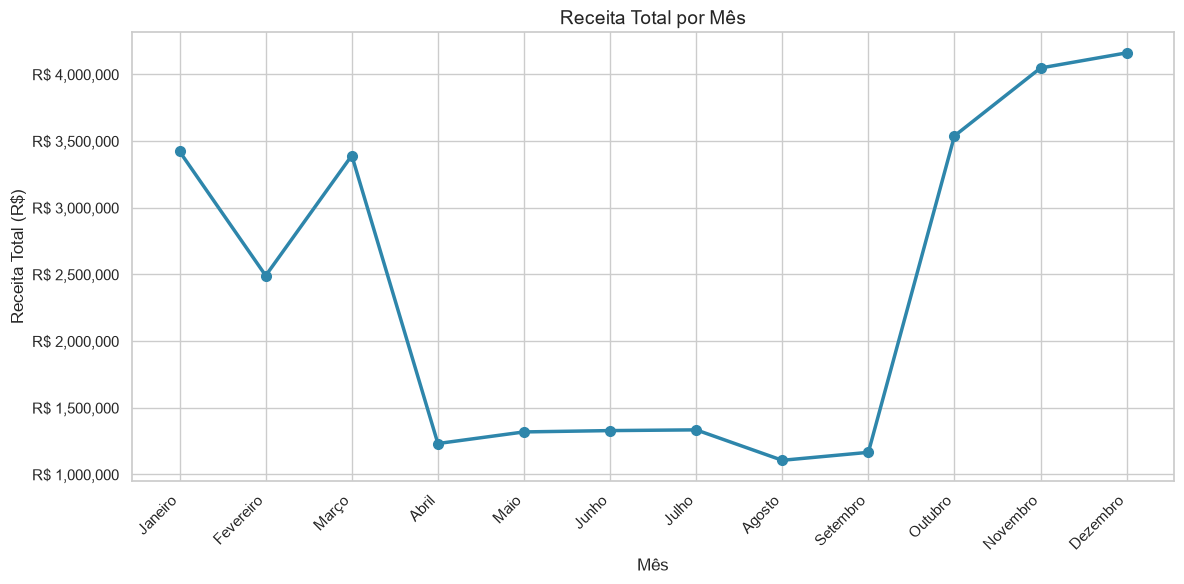

In [27]:
# Receita por mês
por_mes       = metricas["por_mes"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(por_mes["Mês"], por_mes["receita_total"],
        marker="o", linewidth=2.5, color=CORES[0], markersize=7)
ax.set_title("Receita Total por Mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Receita Total (R$)")
ax.set_xticks(por_mes["Mês"])
ax.set_xticklabels(por_mes["Mês Nome"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/graficos/receita_por_mes.png", dpi=150)
plt.show()
plt.close()

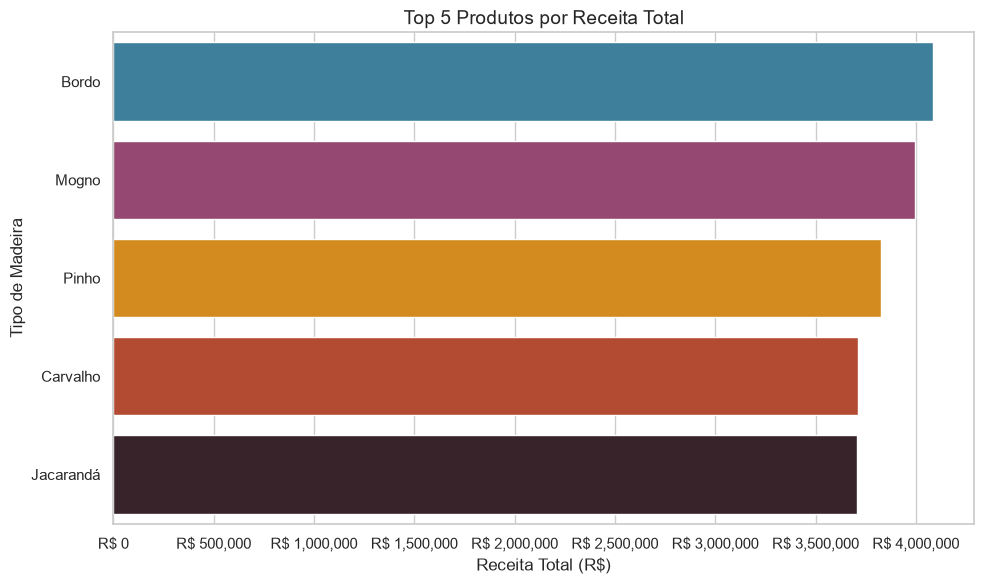

In [28]:
# Top 5 produtos

top_produtos  = metricas["top_produtos"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_produtos, y="Tipo de Madeira", x="receita_total",
                hue="Tipo de Madeira", legend=False, palette=CORES, ax=ax)
ax.set_title("Top 5 Produtos por Receita Total")
ax.set_xlabel("Receita Total (R$)")
ax.set_ylabel("Tipo de Madeira")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/graficos/top_produtos.png", dpi=150)
plt.show()
plt.close()

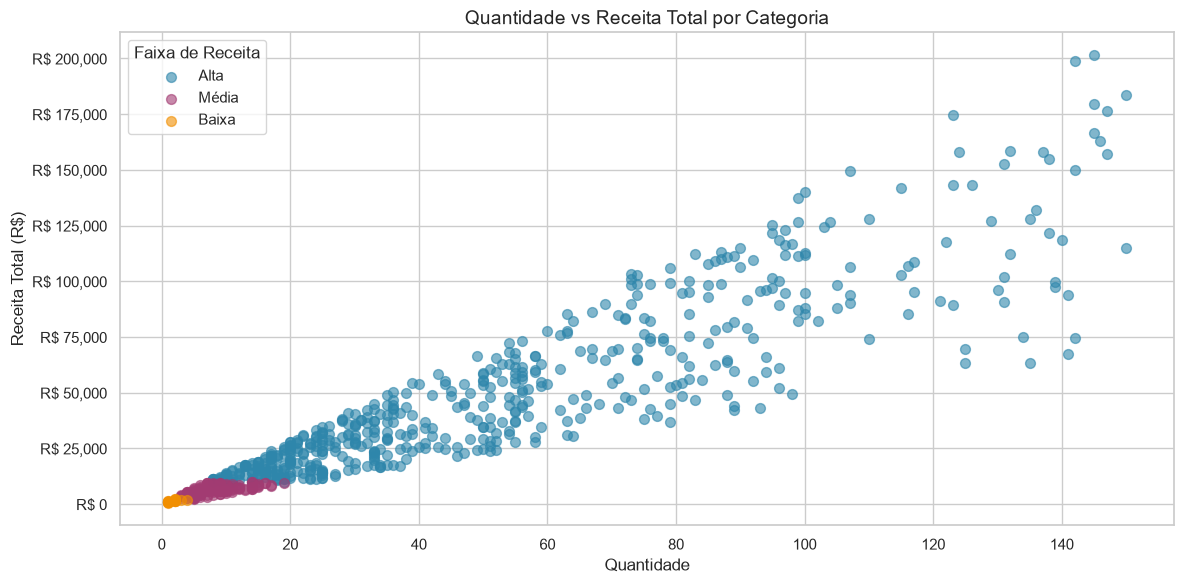

Correlação de Pearson — Quantidade × Receita Total: 0.9202


In [29]:
# Dispersão quantidade × receita por categoria
fig, ax = plt.subplots(figsize=(12, 6))
categorias = df_derivado["Faixa de Receita"].unique()
cores_cat = dict(zip(categorias, CORES))
for cat in categorias:
    subset = df_derivado[df_derivado["Faixa de Receita"] == cat]
    ax.scatter(subset["Quantidade"], subset["Receita Total"],
               label=cat, alpha=0.6, color=cores_cat[cat], s=50)
ax.set_title("Quantidade vs Receita Total por Categoria")
ax.set_xlabel("Quantidade")
ax.set_ylabel("Receita Total (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(title="Faixa de Receita")
plt.tight_layout()
plt.savefig("outputs/graficos/quantidade_vs_receita.png", dpi=150)
plt.show()
plt.close()

correlacao = df_derivado["Quantidade"].corr(df_derivado["Receita Total"])
print(f"Correlação de Pearson — Quantidade × Receita Total: {correlacao:.4f}")

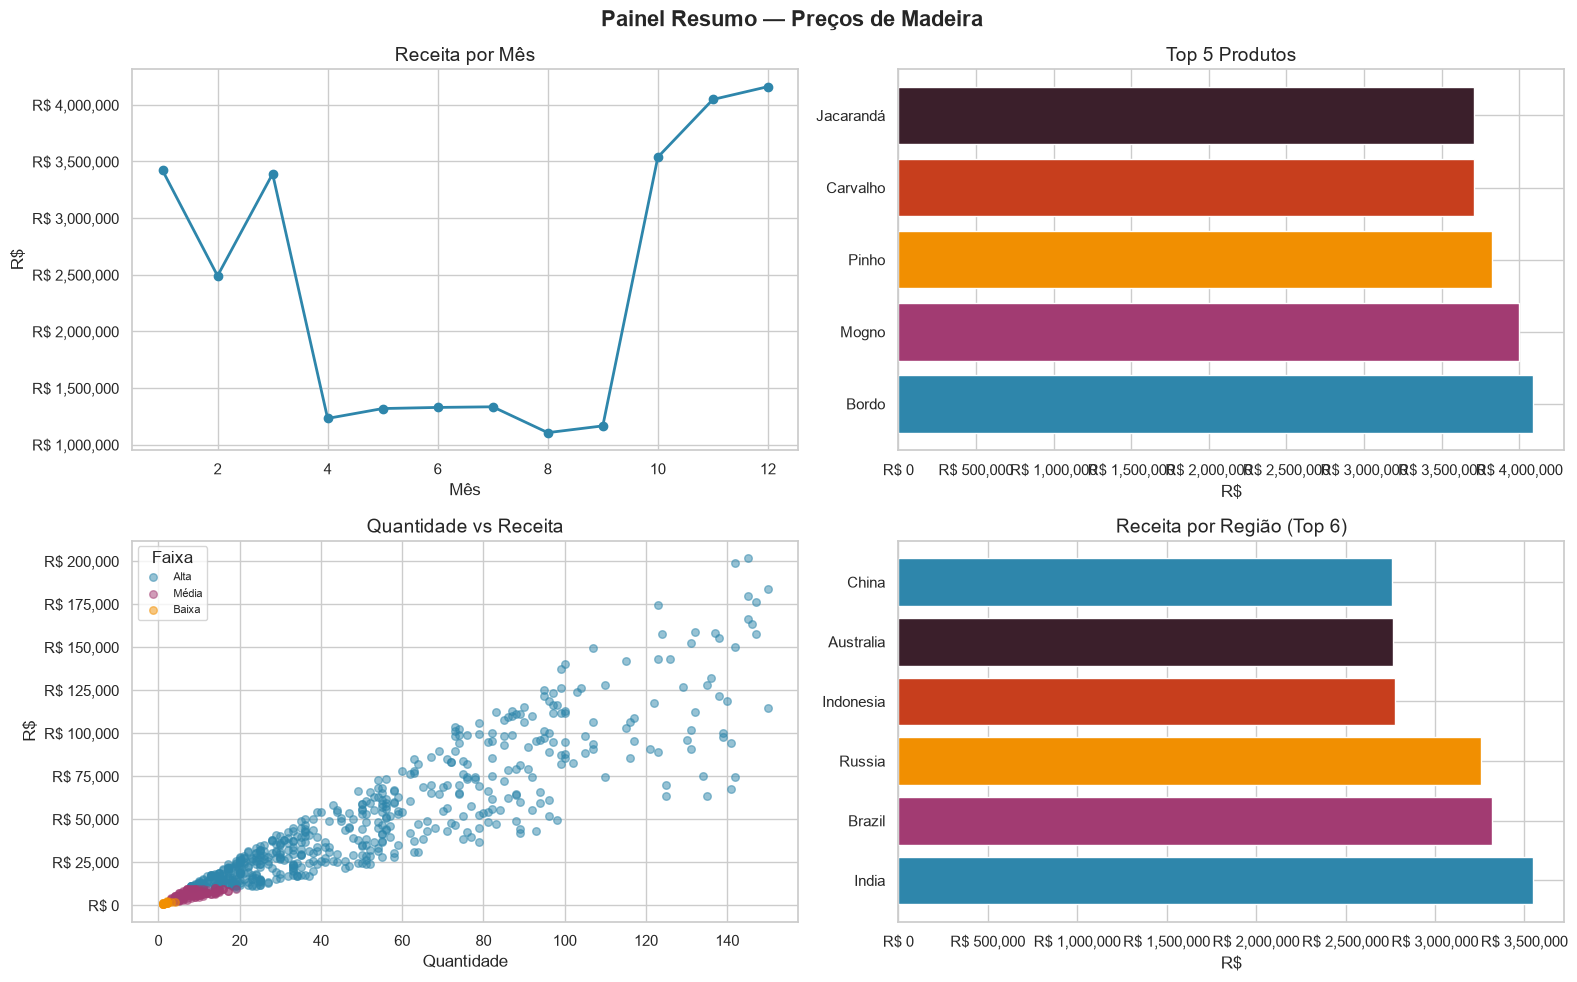

Gráficos salvos em outputs/graficos/


In [30]:
# Painel 2×2 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Painel Resumo — Preços de Madeira", fontsize=16, fontweight="bold")

# [0,0] Linha — receita por mês
axes[0, 0].plot(por_mes["Mês"], por_mes["receita_total"],
                    marker="o", linewidth=2, color=CORES[0])
axes[0, 0].set_title("Receita por Mês")
axes[0, 0].set_xlabel("Mês")
axes[0, 0].set_ylabel("R$")
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

# [0,1] Barras — top 5 produtos
axes[0, 1].barh(top_produtos["Tipo de Madeira"], top_produtos["receita_total"],
                    color=CORES[:len(top_produtos)])
axes[0, 1].set_title("Top 5 Produtos")
axes[0, 1].set_xlabel("R$")
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

# [1,0] Dispersão — quantidade × receita
for cat in categorias:
        subset = df_derivado[df_derivado["Faixa de Receita"] == cat]
        axes[1, 0].scatter(subset["Quantidade"], subset["Receita Total"],
                           label=cat, alpha=0.5, color=cores_cat[cat], s=30)
axes[1, 0].set_title("Quantidade vs Receita")
axes[1, 0].set_xlabel("Quantidade")
axes[1, 0].set_ylabel("R$")
axes[1, 0].legend(title="Faixa", fontsize=8)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

# [1,1] Barras — receita por região
top_regioes = metricas["por_regiao"].head(6)
axes[1, 1].barh(top_regioes["País"], top_regioes["receita_total"],
                    color=CORES[:len(top_regioes)])
axes[1, 1].set_title("Receita por Região (Top 6)")
axes[1, 1].set_xlabel("R$")
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

plt.tight_layout()
plt.savefig("outputs/graficos/painel_resumo.png", dpi=150)
plt.show()
plt.close()

print("Gráficos salvos em outputs/graficos/")

gerar_visualizacoes(df_derivado, metricas)

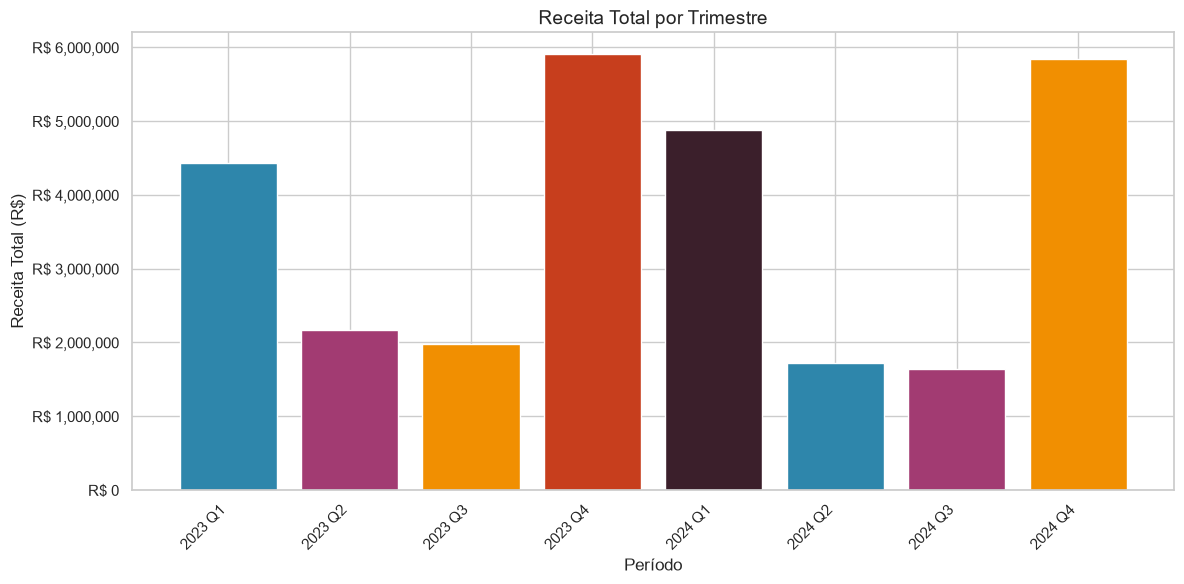

In [31]:
# Por Trimestre

por_trim = metricas["por_trimestre"]
por_trim["período"] = por_trim["Ano"].astype(str) + " " + por_trim["Trimestre"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(por_trim["período"], por_trim["receita_total"], color=CORES[:len(por_trim)])
ax.set_title("Receita Total por Trimestre")
ax.set_xlabel("Período")
ax.set_ylabel("Receita Total (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/graficos/receita_por_trimestre.png", dpi=150)
plt.show()
plt.close()

### RF09 – Organizar o Código em Funções Reutilizáveis e em uma Classe

#### Parte A – Funções reutilizáveis e função de ordem superior

In [32]:
def processar_coluna(df, coluna, funcao_transformacao, nome_saida=None):
    """
    Aplica uma função de transformação a uma coluna do DataFrame.
    Demonstra o uso de funções como argumento (função de ordem superior).
    """
    nome_saida = nome_saida or f"{coluna}_transformado"
    df[nome_saida] = df[coluna].apply(funcao_transformacao)
    return df


# Uso com funções lambda em contextos distintos
df_derivado = processar_coluna(
    df_derivado,
    "Receita Total",
    lambda x: round(x / 1000, 2),
    nome_saida="Receita em Milhares"
)

df_derivado = processar_coluna(
    df_derivado,
    "Quantidade",
    lambda q: "Alto Volume" if q > 50 else "Baixo Volume",
    nome_saida="Perfil de Volume"
)

display(df_derivado[["Receita Total", "Receita em Milhares", "Quantidade", "Perfil de Volume"]].head(10))

,Receita Total,Receita em Milhares,Quantidade,Perfil de Volume
1,44541.90,44.54,54,Alto Volume
4,12417.64,12.42,19,Baixo Volume
6,65726.96,65.73,52,Alto Volume
7,73078.98,73.08,78,Alto Volume
9,37419.25,37.42,55,Alto Volume
10,56784.20,56.78,55,Alto Volume
11,54954.96,54.95,59,Alto Volume
12,18349.44,18.35,16,Baixo Volume
13,65881.78,65.88,94,Alto Volume
14,69746.33,69.75,67,Alto Volume


#### Parte B – Uma classe para organizar o fluxo

In [33]:
def gerar_dataset_vendas(caminho="wood_prices_dataset.csv", seed=42):
    """Lê o CSV base e acrescenta as colunas sintéticas Data e Quantidade."""
    random.seed(seed)
    np.random.seed(seed)

    df = pd.read_csv(caminho)

    sazonalidade = {
        "High":   [10, 11, 12, 1, 2, 3],
        "Medium": list(range(1, 13)),
        "Low":    [4, 5, 6, 7, 8, 9],
    }

    def gerar_data(demand_level):
        mes = random.choice(sazonalidade[demand_level])
        ano = random.choice([2023, 2024])
        if mes in [1, 3, 5, 7, 8, 10, 12]:
            dia = random.randint(1, 31)
        elif mes in [4, 6, 9, 11]:
            dia = random.randint(1, 30)
        else:
            dia = random.randint(1, 28)
        return date(ano, mes, dia).strftime("%Y-%m-%d")

    def gerar_quantidade(demand_level, availability):
        faixas = {
            ("High",   "Abundant"): (80, 150),
            ("High",   "Moderate"): (50, 100),
            ("High",   "Scarce"):   (10,  40),
            ("Medium", "Abundant"): (40,  80),
            ("Medium", "Moderate"): (20,  60),
            ("Medium", "Scarce"):   ( 5,  25),
            ("Low",    "Abundant"): (10,  40),
            ("Low",    "Moderate"): ( 5,  20),
            ("Low",    "Scarce"):   ( 1,  10),
        }
        chave = (demand_level, availability)
        minimo, maximo = faixas.get(chave, (10, 50))
        return random.randint(minimo, maximo)

    df["Data"]       = df["Demand Level"].apply(gerar_data)
    df["Quantidade"] = df.apply(
        lambda row: gerar_quantidade(row["Demand Level"], row["Availability"]), axis=1
    )
    return df

Parte 2 — AnalisadorDeVendas: __init__ + carregar() + limpar()

In [34]:
class AnalisadorDeVendas:
    """Encapsula o fluxo completo de análise dos dados de madeira."""

    def __init__(self, caminho_arquivo):
        self.caminho_arquivo   = caminho_arquivo
        self.df_bruto          = None
        self.df_limpo          = None
        self.df_derivado       = None
        self.metricas          = {}
        self.clientes          = None
        self.estatisticas      = {}
        self.relatorio_limpeza = {}

    def carregar(self):
        """Lê o CSV e guarda o DataFrame bruto."""
        self.df_bruto = gerar_dataset_vendas(self.caminho_arquivo)
        print(f"[Analisador] {len(self.df_bruto)} registros lidos.")

    def limpar(self):
        """Limpa e traduz os dados."""
        import re

        df = self.df_bruto.copy()

        # 1. Espaços extras
        colunas_texto = ["Wood Type", "Country", "Supply Source",
                         "Quality Rating", "Demand Level", "Availability"]
        for col in colunas_texto:
            if col in df.columns:
                df[col] = df[col].astype("string").str.strip()

        # 2. Data
        df["Data"] = pd.to_datetime(df["Data"], errors="coerce")
        removidos_data = int(df["Data"].isna().sum())
        df = df.dropna(subset=["Data"]).copy()

        # 3. Nulos críticos
        antes = len(df)
        df = df.dropna(subset=["Price (USD)", "Quantidade"]).copy()
        removidos_nulos = int(antes - len(df))

        # 4. Tipos numéricos
        df["Price (USD)"] = pd.to_numeric(df["Price (USD)"], errors="coerce")
        df["Quantidade"]  = pd.to_numeric(df["Quantidade"],  errors="coerce")
        df["Popularity"]  = pd.to_numeric(df["Popularity"],  errors="coerce")
        df = df.dropna(subset=["Price (USD)", "Quantidade"]).copy()
        df["Quantidade"]  = df["Quantidade"].astype(int)
        df["Price (USD)"] = df["Price (USD)"].astype(float)

        # 5. Padronizar Country
        def padronizar_pais(valor):
            valor_limpo = re.sub(r"-", " ", str(valor))
            valor_limpo = re.sub(r"[^A-Za-z\s]", "", valor_limpo)
            valor_limpo = re.sub(r"\s+", " ", valor_limpo).strip()
            return " ".join(
                w if (len(w) <= 3 and w.isupper()) else w.title()
                for w in valor_limpo.split()
            )
        df["Country"] = df["Country"].apply(padronizar_pais)

        # 6. Quality Rating inválido
        antes = len(df)
        df = df[df["Quality Rating"].isin({"Low", "Medium", "High"})].copy()
        removidos_invalidos = int(antes - len(df))

        # 7. Tradução de colunas
        df = df.rename(columns={
            "Wood Type":      "Tipo de Madeira",
            "Country":        "País",
            "Price (USD)":    "Preço (USD)",
            "Supply Source":  "Fonte de Fornecimento",
            "Quality Rating": "Avaliação de Qualidade",
            "Popularity":     "Popularidade",
            "Demand Level":   "Nível de Demanda",
            "Availability":   "Disponibilidade",
        })

        traducoes = {
            "Tipo de Madeira": {
                "Oak": "Carvalho", "Pine": "Pinho", "Maple": "Bordo",
                "Walnut": "Nogueira", "Cherry": "Cerejeira", "Bamboo": "Bambu",
                "Teak": "Teca", "Rosewood": "Jacarandá", "Mahogany": "Mogno",
                "Cedar": "Cedro",
            },
            "Fonte de Fornecimento": {"Local": "Local", "Imported": "Importado"},
            "Avaliação de Qualidade": {"Low": "Baixa", "Medium": "Média", "High": "Alta"},
            "Nível de Demanda":       {"Low": "Baixa", "Medium": "Média", "High": "Alta"},
            "Disponibilidade":        {
                "Scarce": "Escassa", "Moderate": "Moderada", "Abundant": "Abundante"
            },
        }
        for col, mapa in traducoes.items():
            if col in df.columns:
                df[col] = df[col].map(mapa).fillna(df[col])

        # 8. Conversão USD → BRL e remoção do preço em dólar
        df["Preço (BRL)"] = (df["Preço (USD)"] * TAXA_USD_BRL).round(2)
        df = df.drop(columns=["Preço (USD)"])

        self.relatorio_limpeza = {
            "registros_iniciais":       len(self.df_bruto),
            "removidos_data_invalida":  removidos_data,
            "removidos_nulos_criticos": removidos_nulos,
            "removidos_invalidos":      removidos_invalidos,
            "total_removidos":          int(len(self.df_bruto) - len(df)),
            "registros_finais":         len(df),
        }

        print("=" * 45)
        print("         RELATÓRIO DE LIMPEZA")
        print("=" * 45)
        for k, v in self.relatorio_limpeza.items():
            print(f"  {k:<30}: {v:>6}")
        print("=" * 45)

        self.df_limpo = df

    def transformar(self):
        """Cria colunas derivadas e coluna Cliente."""
        df = self.df_limpo.copy()

        df["Receita Total"] = df["Quantidade"] * df["Preço (BRL)"]

        df["Mês"]       = df["Data"].dt.month
        df["Ano"]       = df["Data"].dt.year
        df["Trimestre"] = df["Data"].dt.quarter.apply(lambda q: f"Q{q}")

        meses = {1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril",
                 5: "Maio", 6: "Junho", 7: "Julho", 8: "Agosto",
                 9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"}
        df["Mês Nome"] = df["Mês"].map(meses)

        condicoes = [
            df["Receita Total"] <= 2203,
            (df["Receita Total"] > 2203) & (df["Receita Total"] <= 9732),
            df["Receita Total"] > 9732,
        ]
        df["Faixa de Receita"] = np.select(condicoes, ["Baixa", "Média", "Alta"],
                                           default="Indefinida")

        np.random.seed(42)
        clientes = [f"Cliente_{i:03d}" for i in range(1, 51)]
        df["Cliente"] = np.random.choice(clientes, size=len(df))

        df["Receita em Milhares"] = (df["Receita Total"] / 1000).round(2)
        df["Perfil de Volume"]    = df["Quantidade"].apply(
            lambda q: "Alto Volume" if q > 50 else "Baixo Volume"
        )

        self.df_derivado = df

    def analisar(self):
        """Calcula métricas, segmentação e estatísticas NumPy."""
        df = self.df_derivado

        # Métricas groupby
        self.metricas["por_mes"] = (
            df.groupby(["Mês", "Mês Nome"])
            .agg(
                receita_total=("Receita Total", "sum"),
                quantidade=("Quantidade", "sum"),
                n_vendas=("Receita Total", "count"))
            .round(2).reset_index().sort_values("Mês").reset_index(drop=True)
        )
        self.metricas["top_produtos"] = (
            df.groupby("Tipo de Madeira")
            .agg(receita_total=("Receita Total", "sum"))
            .round(2).reset_index()
            .sort_values("receita_total", ascending=False)
            .head(5).reset_index(drop=True)
        )
        self.metricas["por_categoria"] = (
            df.groupby("Faixa de Receita")
            .agg(
                receita_total=("Receita Total", "sum"),
                n_vendas=("Receita Total", "count"))
            .round(2).reset_index()
            .sort_values("receita_total", ascending=False).reset_index(drop=True)
        )
        self.metricas["por_regiao"] = (
            df.groupby("País")
            .agg(
                receita_total=("Receita Total", "sum"),
                ticket_medio=("Receita Total", "mean"),
                n_vendas=("Receita Total", "count"))
            .round(2).reset_index()
            .sort_values("receita_total", ascending=False).reset_index(drop=True)
        )

        # Segmentação de clientes
        self.clientes = (
            df.groupby("Cliente")
            .agg(total_gasto=("Receita Total", "sum"))
            .round(2).reset_index()
            .sort_values("total_gasto", ascending=False).reset_index(drop=True)
        )
        self.clientes["segmento"] = self.clientes["total_gasto"].apply(
            lambda x: "Bronze" if x < 460000 else ("Prata" if x <= 550000 else "Ouro")
        )

        # NumPy
        receitas = df["Receita Total"].to_numpy()
        media    = np.mean(receitas)
        self.estatisticas = {
            "media":           round(float(np.mean(receitas)),       2),
            "mediana":         round(float(np.median(receitas)),     2),
            "desvio_padrao":   round(float(np.std(receitas, ddof=0)), 2),
            "total":           round(float(np.sum(receitas)),        2),
            "minimo":          round(float(np.min(receitas)),        2),
            "maximo":          round(float(np.max(receitas)),        2),
            "n_acima_media":   int(np.sum(receitas > media)),
            "pct_acima_media": round(float(np.mean(receitas > media) * 100), 2),
            "p25":             round(float(np.percentile(receitas, 25)), 2),
            "p50":             round(float(np.percentile(receitas, 50)), 2),
            "p75":             round(float(np.percentile(receitas, 75)), 2),
        }

    def visualizar(self):
        """Gera e exporta as quatro figuras obrigatórias + bônus B04."""
        os.makedirs("outputs/graficos", exist_ok=True)
        df         = self.df_derivado
        por_mes    = self.metricas["por_mes"]
        top_prod   = self.metricas["top_produtos"]
        por_regiao = self.metricas["por_regiao"]
        categorias = df["Faixa de Receita"].unique()
        cores_cat  = dict(zip(categorias, CORES))

        fmt = plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}")

        # 1. Linha – receita por mês
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(por_mes["Mês"], por_mes["receita_total"],
                marker="o", linewidth=2.5, color=CORES[0], markersize=7)
        ax.set_title("Receita Total por Mês")
        ax.set_xlabel("Mês")
        ax.set_ylabel("Receita Total (R$)")
        ax.set_xticks(por_mes["Mês"])
        ax.set_xticklabels(por_mes["Mês Nome"], rotation=45, ha="right")
        ax.yaxis.set_major_formatter(fmt)
        plt.tight_layout()
        plt.savefig("outputs/graficos/receita_por_mes.png", dpi=150)
        plt.show()
        plt.close()

        # 2. Barras – top 5 produtos
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=top_prod, y="Tipo de Madeira", x="receita_total",
                    hue="Tipo de Madeira", legend=False, palette=CORES[:5], ax=ax)
        ax.set_title("Top 5 Produtos por Receita Total")
        ax.set_xlabel("Receita Total (R$)")
        ax.set_ylabel("Tipo de Madeira")
        ax.xaxis.set_major_formatter(fmt)
        plt.tight_layout()
        plt.savefig("outputs/graficos/top_produtos.png", dpi=150)
        plt.show()
        plt.close()

        # 3. Dispersão – quantidade × receita por categoria
        fig, ax = plt.subplots(figsize=(12, 6))
        for cat in categorias:
            sub = df[df["Faixa de Receita"] == cat]
            ax.scatter(sub["Quantidade"], sub["Receita Total"],
                       label=cat, alpha=0.6, color=cores_cat[cat], s=50)
        ax.set_title("Quantidade vs Receita Total por Categoria")
        ax.set_xlabel("Quantidade")
        ax.set_ylabel("Receita Total (R$)")
        ax.yaxis.set_major_formatter(fmt)
        ax.legend(title="Faixa de Receita")
        plt.tight_layout()
        plt.savefig("outputs/graficos/quantidade_vs_receita.png", dpi=150)
        plt.show()
        plt.close()

        # 4. Painel 2×2
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle("Painel Resumo — Análise de Preços de Madeira",
                     fontsize=16, fontweight="bold")

        axes[0, 0].plot(por_mes["Mês"], por_mes["receita_total"],
                        marker="o", linewidth=2, color=CORES[0])
        axes[0, 0].set_title("Receita por Mês")
        axes[0, 0].set_xlabel("Mês")
        axes[0, 0].set_ylabel("R$")
        axes[0, 0].yaxis.set_major_formatter(fmt)

        axes[0, 1].barh(top_prod["Tipo de Madeira"], top_prod["receita_total"],
                        color=CORES[:len(top_prod)])
        axes[0, 1].set_title("Top 5 Produtos")
        axes[0, 1].set_xlabel("R$")
        axes[0, 1].xaxis.set_major_formatter(fmt)

        for cat in categorias:
            sub = df[df["Faixa de Receita"] == cat]
            axes[1, 0].scatter(sub["Quantidade"], sub["Receita Total"],
                               label=cat, alpha=0.5, color=cores_cat[cat], s=30)
        axes[1, 0].set_title("Quantidade vs Receita")
        axes[1, 0].set_xlabel("Quantidade")
        axes[1, 0].set_ylabel("R$")
        axes[1, 0].legend(title="Faixa", fontsize=8)
        axes[1, 0].yaxis.set_major_formatter(fmt)

        top_reg = por_regiao.head(6)
        axes[1, 1].barh(top_reg["País"], top_reg["receita_total"],
                        color=CORES[:len(top_reg)])
        axes[1, 1].set_title("Receita por Região (Top 6)")
        axes[1, 1].set_xlabel("R$")
        axes[1, 1].xaxis.set_major_formatter(fmt)

        plt.tight_layout()
        plt.savefig("outputs/graficos/painel_resumo.png", dpi=150)
        plt.show()
        plt.close()

        # Bônus B04 – boxplot
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.boxplot(data=df, x="Tipo de Madeira", y="Receita Total",
                    hue="Tipo de Madeira", legend=False, palette=CORES, ax=ax)
        ax.set_title("Distribuição da Receita por Tipo de Madeira")
        ax.set_xlabel("Tipo de Madeira")
        ax.set_ylabel("Receita Total (R$)")
        ax.yaxis.set_major_formatter(fmt)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("outputs/graficos/boxplot_receita.png", dpi=150)
        plt.show()
        plt.close()

        # Bônus B04 – mapa de calor
        pivot = df.pivot_table(values="Receita Total", index="Tipo de Madeira",
                               columns="Mês Nome", aggfunc="mean")
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
                    linewidths=0.5)
        ax.set_title("Receita Média — Tipo de Madeira × Mês")
        ax.set_xlabel("Mês")
        ax.set_ylabel("Tipo de Madeira")
        plt.tight_layout()
        plt.savefig("outputs/graficos/heatmap_receita.png", dpi=150)
        plt.show()
        plt.close()

        print("[Analisador] Gráficos salvos em outputs/graficos/")

    def resumo(self):
        """Imprime um resumo executivo."""
        print("\n" + "=" * 55)
        print("   RESUMO EXECUTIVO — ANÁLISE DE PREÇOS DE MADEIRA")
        print("=" * 55)
        print(f"  Registros processados : {self.relatorio_limpeza.get('registros_finais', '—')}")
        print(f"  Receita total         : R$ {self.estatisticas.get('total', 0):>15,.2f}")
        print(f"  Ticket médio          : R$ {self.estatisticas.get('media', 0):>15,.2f}")
        print(f"  Mediana               : R$ {self.estatisticas.get('mediana', 0):>15,.2f}")
        print(f"  Desvio padrão         : R$ {self.estatisticas.get('desvio_padrao', 0):>15,.2f}")
        print(f"  Percentil 25          : R$ {self.estatisticas.get('p25', 0):>15,.2f}")
        print(f"  Percentil 75          : R$ {self.estatisticas.get('p75', 0):>15,.2f}")
        print(f"  Vendas acima da média : {self.estatisticas.get('n_acima_media', 0)} "
              f"({self.estatisticas.get('pct_acima_media', 0)}%)")
        print("\n  Distribuição de clientes por segmento:")
        print(self.clientes["segmento"].value_counts().to_string())
        print("=" * 55)

### RF10 – Exportar Resultados em CSV e JSON

In [35]:
def exportar_resultados(metricas, clientes, estatisticas):
    """Exporta os resultados do projeto em CSV e JSON."""
    os.makedirs("outputs", exist_ok=True)

    # CSV — métricas por mês
    metricas["por_mes"].to_csv("outputs/metricas_por_mes.csv",
                               index=False, encoding="utf-8-sig")

    # CSV — segmentação de clientes
    clientes.to_csv("outputs/segmentacao_clientes.csv",
                    index=False, encoding="utf-8-sig")

    # JSON — estatísticas gerais
    serializavel = {k: round(float(v), 2) for k, v in estatisticas.items()}
    caminho = "outputs/estatisticas_gerais.json"
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(serializavel, f, indent=4, ensure_ascii=False)

    # Leitura de volta para confirmar a escrita
    with open(caminho, "r", encoding="utf-8") as f:
        conferencia = json.load(f)

    print("[Export] Arquivos gerados:")
    print("  outputs/metricas_por_mes.csv")
    print("  outputs/segmentacao_clientes.csv")
    print("  outputs/estatisticas_gerais.json")
    print(f"\n[Export] JSON lido de volta com sucesso: {list(conferencia.keys())}")

### RF11 – Executar o Fluxo Completo (Ponto de Entrada)

A função `main()` abaixo centraliza o fluxo obrigatório do projeto na ordem:

**carregar → inspecionar → limpar → transformar → analisar → visualizar → resumo**.

A chamada de `main()` é realizada ao final da célula de implementação, depois que todas as classes e funções necessárias já foram definidas.


   SALESINSIGHT PY — Análise de Dados de Madeira
[Analisador] 1000 registros lidos.
         RELATÓRIO DE LIMPEZA
  registros_iniciais            :   1000
  removidos_data_invalida       :      0
  removidos_nulos_criticos      :      0
  removidos_invalidos           :      0
  total_removidos               :      0
  registros_finais              :   1000


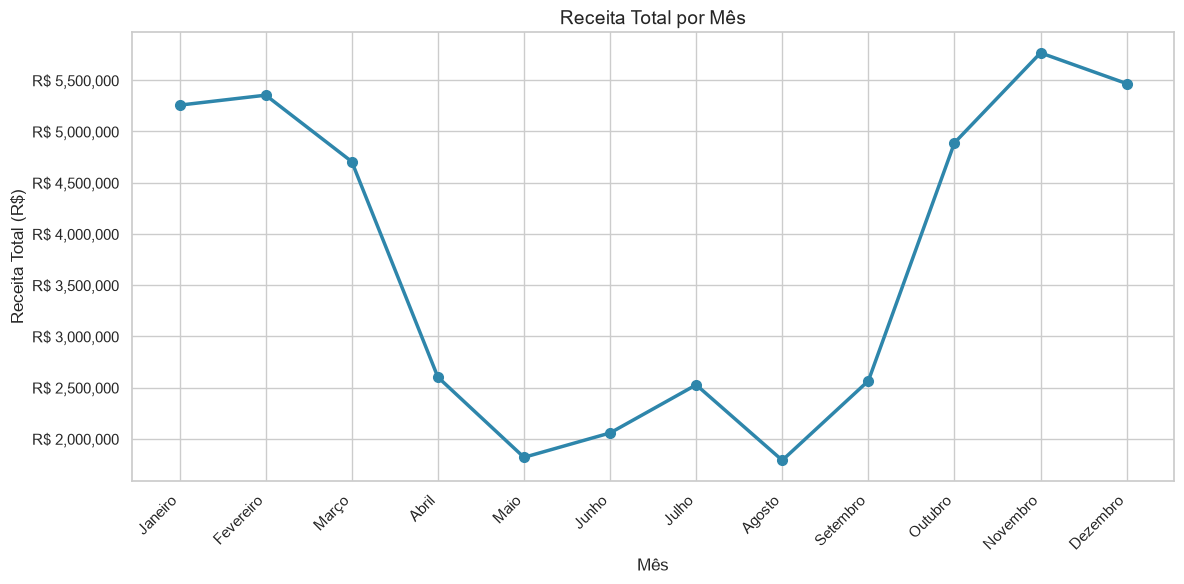

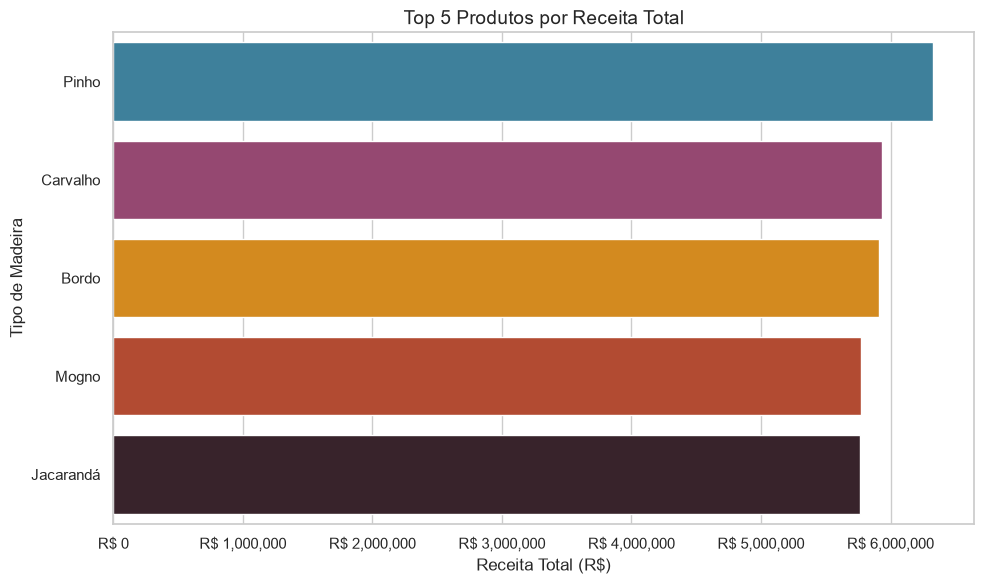

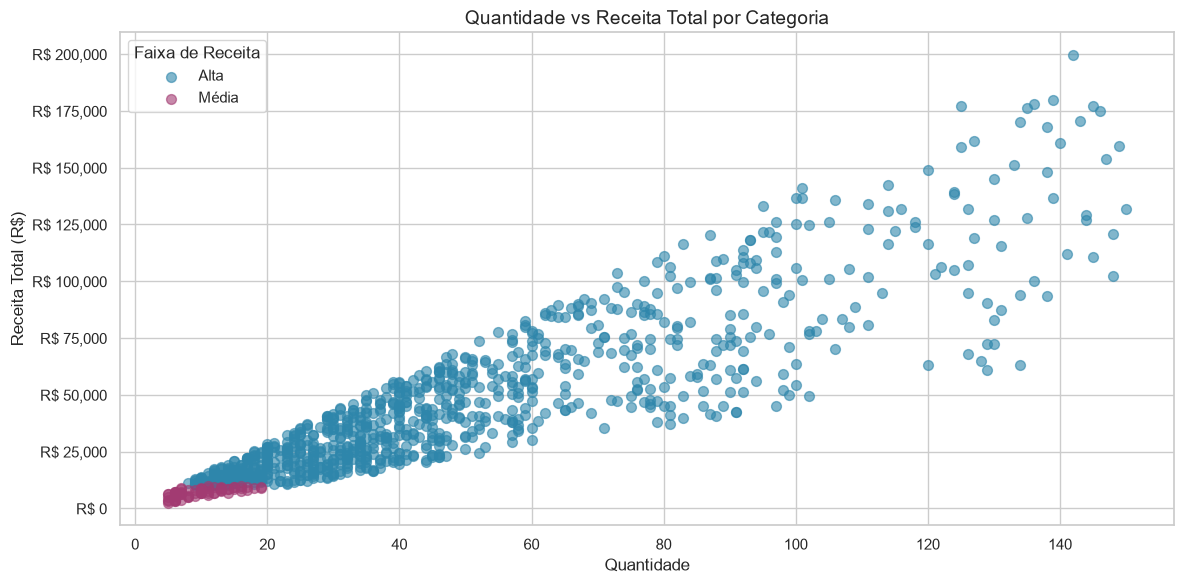

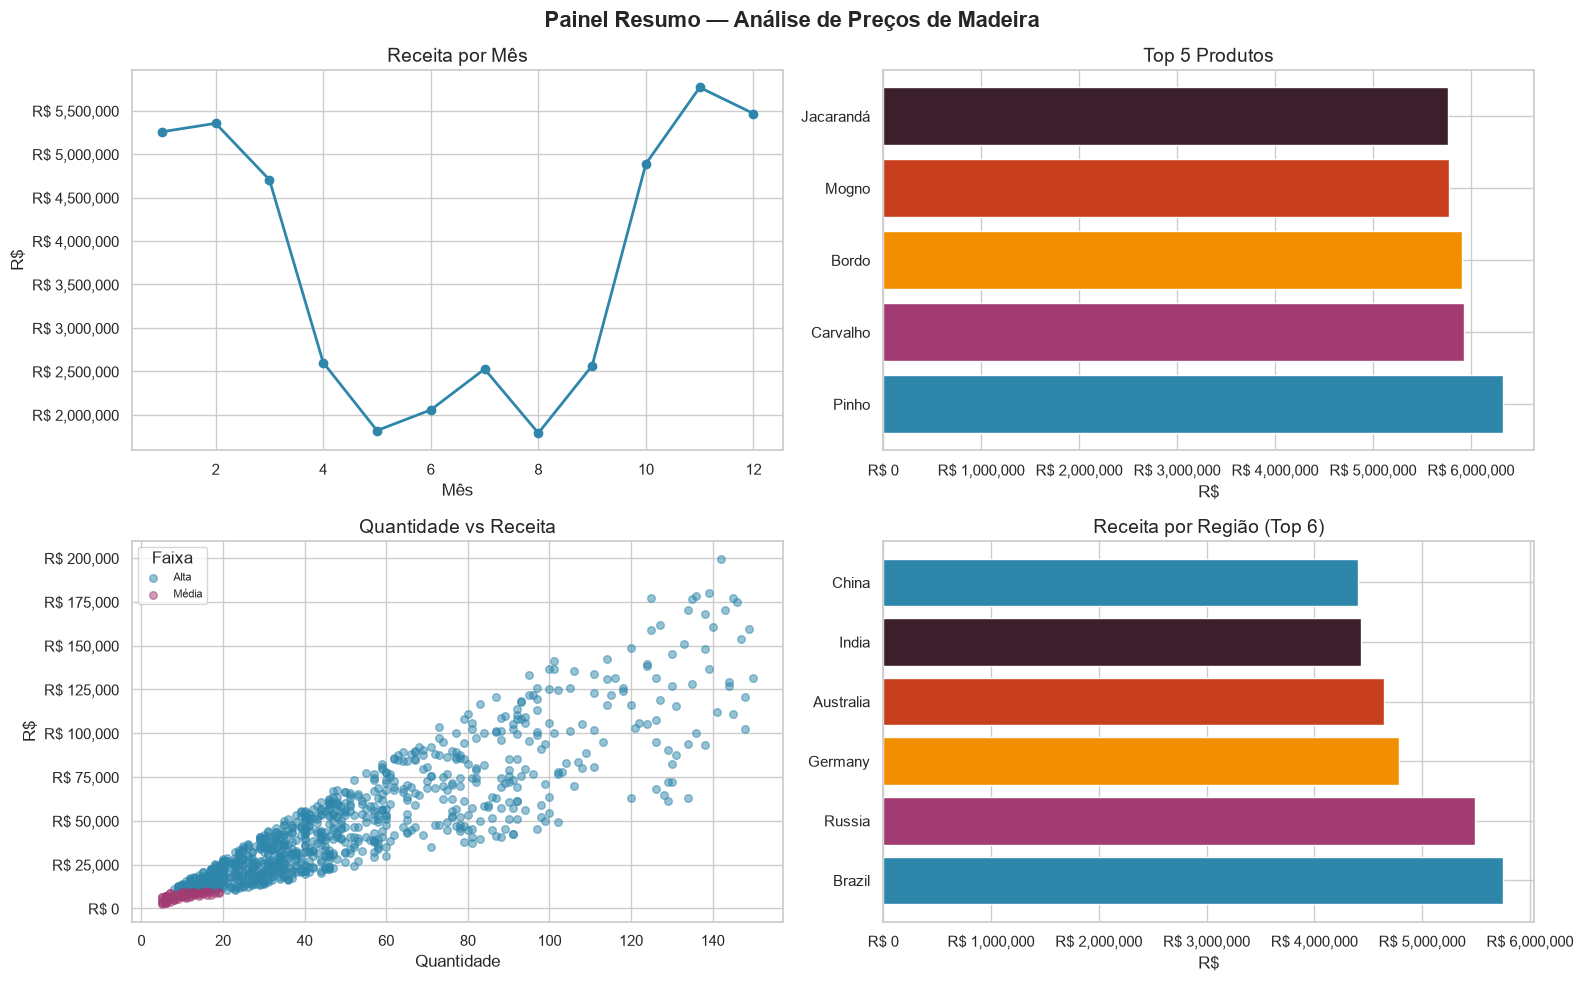

C:\Users\caroo\AppData\Local\Temp\ipykernel_15544\2613500166.py:316: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x="Tipo de Madeira", y="Receita Total",


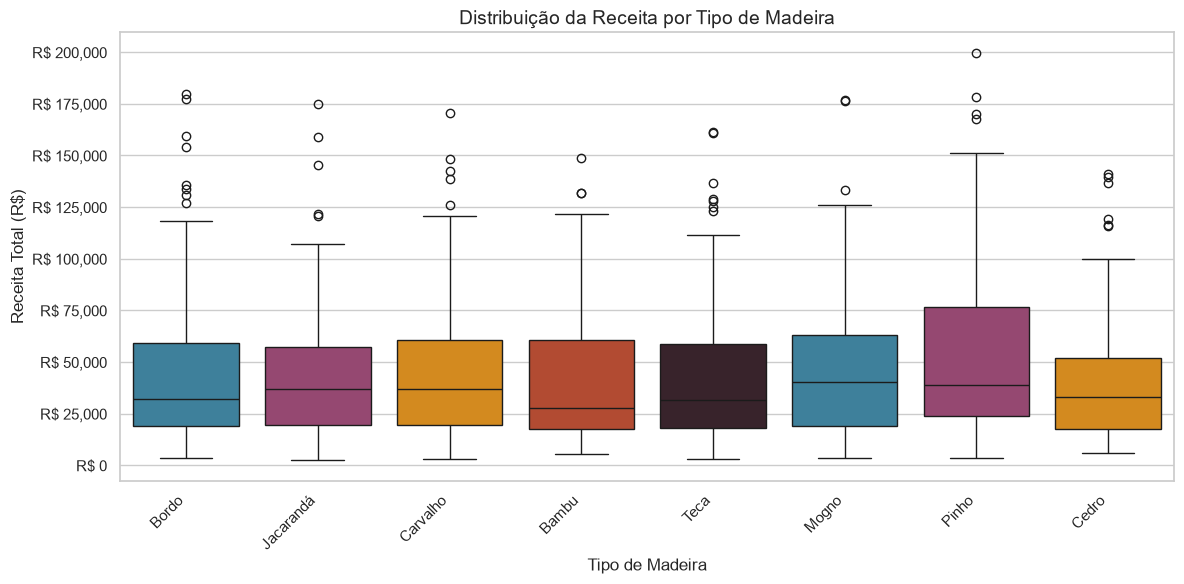

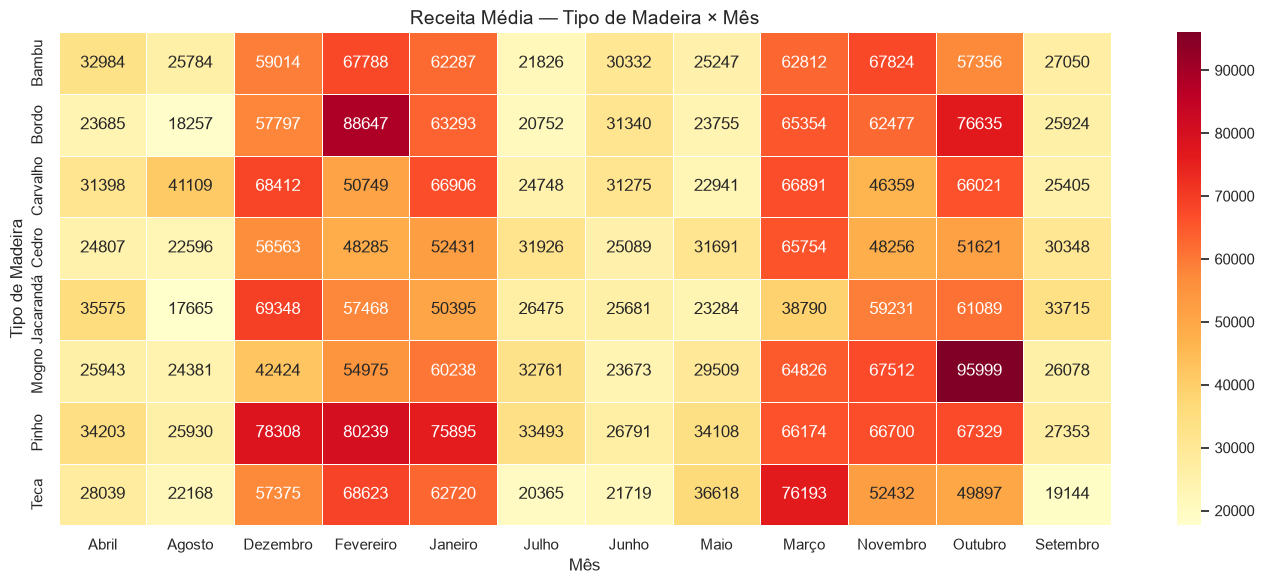

[Analisador] Gráficos salvos em outputs/graficos/

   RESUMO EXECUTIVO — ANÁLISE DE PREÇOS DE MADEIRA
  Registros processados : 1000
  Receita total         : R$   44,798,544.05
  Ticket médio          : R$       44,798.54
  Mediana               : R$       35,115.59
  Desvio padrão         : R$       34,904.84
  Percentil 25          : R$       18,374.79
  Percentil 75          : R$       59,788.04
  Vendas acima da média : 384 (38.4%)

  Distribuição de clientes por segmento:
segmento
Ouro      44
Prata      5
Bronze     1
[Export] Arquivos gerados:
  outputs/metricas_por_mes.csv
  outputs/segmentacao_clientes.csv
  outputs/estatisticas_gerais.json

[Export] JSON lido de volta com sucesso: ['media', 'mediana', 'desvio_padrao', 'total', 'minimo', 'maximo', 'n_acima_media', 'pct_acima_media', 'p25', 'p50', 'p75']

[CONCLUÍDO] Fluxo finalizado com sucesso.


In [36]:
def main():
    print("=" * 60)
    print("   SALESINSIGHT PY — Análise de Dados de Madeira")
    print("=" * 60)

    # Etapas 1 a 6 — fluxo pela classe
    analisador = AnalisadorDeVendas("wood_prices_dataset.csv")
    analisador.carregar()
    analisador.limpar()
    analisador.transformar()
    analisador.analisar()
    analisador.visualizar()
    analisador.resumo()

    exportar_resultados(
        analisador.metricas,
        analisador.clientes,
        analisador.estatisticas,
    )

    print("\n[CONCLUÍDO] Fluxo finalizado com sucesso.")


if __name__ == "__main__":
    main()

### 4. Requisitos Bônus (Opcionais)

Os itens abaixo não são obrigatórios e não afetam a nota. São caminhos de aprofundamento para quem terminar antes do prazo e quiser enriquecer o portfólio — podem ser destacados no README e no vídeo como diferencial.

•	B01 – Herança: criar uma subclasse (ex.: AnalisadorComProjecao) que herde de AnalisadorDeVendas usando super(). Conteúdo além do Módulo 01.

•	B02 – Projeção simples de tendência: estimar a receita dos próximos meses por média móvel dos últimos meses. Modelos preditivos serão estudados na Semana 13.

•	B03 – merge ou pivot: enriquecer o dataset com uma tabela auxiliar (ex.: metas por região) ou montar uma tabela cruzada mês × categoria.

•	B04 – Gráficos adicionais: histograma, boxplot, mapa de calor ou barras agrupadas, além das quatro figuras obrigatórias.

•	B05 – Percentis: calcular np.percentile para os quartis da receita. A interpretação de quartis será trabalhada na Semana 12.


B01 + B02 — AnalisadorComProjecao

In [37]:
class AnalisadorComProjecao(AnalisadorDeVendas):
    """
    Subclasse que adiciona projeção de receita por média móvel.
    B01 — herança com super()
    B02 — projeção simples de tendência
    """

    def __init__(self, caminho_arquivo, janela=3):
        super().__init__(caminho_arquivo)
        self.janela   = janela
        self.projecao = None

    def projetar(self, n_meses=3):
        """Estima a receita dos próximos meses por média móvel."""
        por_mes = self.metricas.get("por_mes")
        if por_mes is None:
            raise RuntimeError("Execute analisar() antes de projetar().")

        ultimos     = por_mes["receita_total"].tail(self.janela).values
        media_movel = np.mean(ultimos)

        ultimo_mes = int(por_mes["Mês"].iloc[-1])
        meses_map  = {1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril",
                      5: "Maio", 6: "Junho", 7: "Julho", 8: "Agosto",
                      9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro"}

        linhas = []
        for i in range(1, n_meses + 1):
            mes_proj = (ultimo_mes + i - 1) % 12 + 1
            linhas.append({
                "Mês":          mes_proj,
                "Mês Nome":     meses_map[mes_proj],
                "receita_proj": round(media_movel, 2),
                "tipo":         "Projeção",
            })

        self.projecao = pd.DataFrame(linhas)

        print("\n" + "=" * 45)
        print(f"  PROJEÇÃO — MÉDIA MÓVEL ({self.janela} meses)")
        print("=" * 45)
        print(self.projecao.to_string(index=False))

        # Gráfico histórico + projeção
        fig, ax = plt.subplots(figsize=(13, 6))
        ax.plot(por_mes["Mês"], por_mes["receita_total"],
                marker="o", label="Histórico", color=CORES[0], linewidth=2)
        ax.plot(self.projecao["Mês"], self.projecao["receita_proj"],
                marker="s", linestyle="--", label="Projeção",
                color=CORES[2], linewidth=2)
        ax.set_title(f"Receita Histórica + Projeção (MM {self.janela} meses)")
        ax.set_xlabel("Mês")
        ax.set_ylabel("Receita (R$)")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
        ax.legend()
        plt.tight_layout()
        os.makedirs("outputs/graficos", exist_ok=True)
        plt.savefig("outputs/graficos/projecao_receita.png", dpi=150)
        plt.show()
        plt.close()

In [38]:
# Instanciar e processar o analisador para que esteja disponível para as células de bônus
analisador = AnalisadorDeVendas("wood_prices_dataset.csv")
analisador.carregar()
analisador.limpar()
analisador.transformar()
analisador.analisar()

[Analisador] 1000 registros lidos.
         RELATÓRIO DE LIMPEZA
  registros_iniciais            :   1000
  removidos_data_invalida       :      0
  removidos_nulos_criticos      :      0
  removidos_invalidos           :      0
  total_removidos               :      0
  registros_finais              :   1000


B03 — Pivot Faixa de Receita × Mês

In [39]:
# Bônus B03 — merge / pivot
pivot_faixa_mes = analisador.df_derivado.pivot_table(
    values="Receita Total",
    index="Faixa de Receita",
    columns="Mês Nome",
    aggfunc="sum",
    fill_value=0,
).round(2)

pivot_faixa_mes.to_csv("outputs/pivot_faixa_mes.csv", encoding="utf-8-sig")

print("[Bônus B03] Pivot receita — Faixa × Mês:")
print(pivot_faixa_mes.to_string())

[Bônus B03] Pivot receita — Faixa × Mês:
Mês Nome               Abril      Agosto   Dezembro   Fevereiro     Janeiro       Julho       Junho        Maio       Março    Novembro     Outubro    Setembro
Faixa de Receita                                                                                                                                               
Alta              2547968.87  1735488.70  5467301.0  5345210.67  5250244.92  2425860.21  2019951.32  1753448.80  4705279.41  5738414.65  4882429.51  2454486.47
Média               53453.89    54139.57        0.0     9096.60     6827.04   100490.31    36762.54    65124.23        0.00    28966.71     6691.56   110907.07


B04 — já está dentro do visualizar() (boxplot + heatmap)

C:\Users\caroo\AppData\Local\Temp\ipykernel_15544\2967936478.py:3: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=analisador.df_derivado, x="Tipo de Madeira", y="Receita Total",


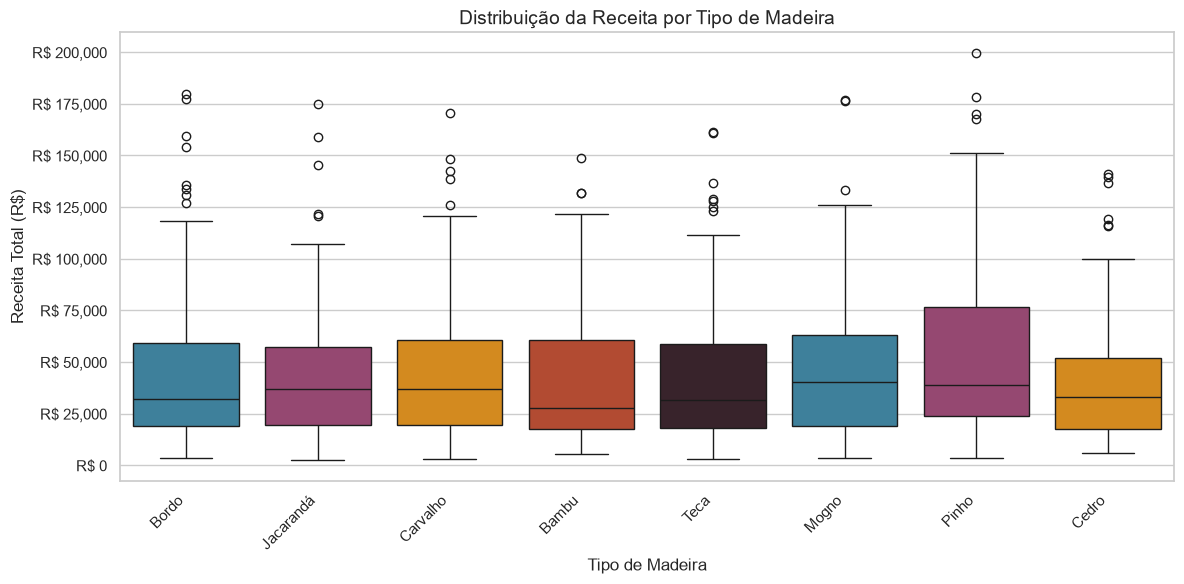

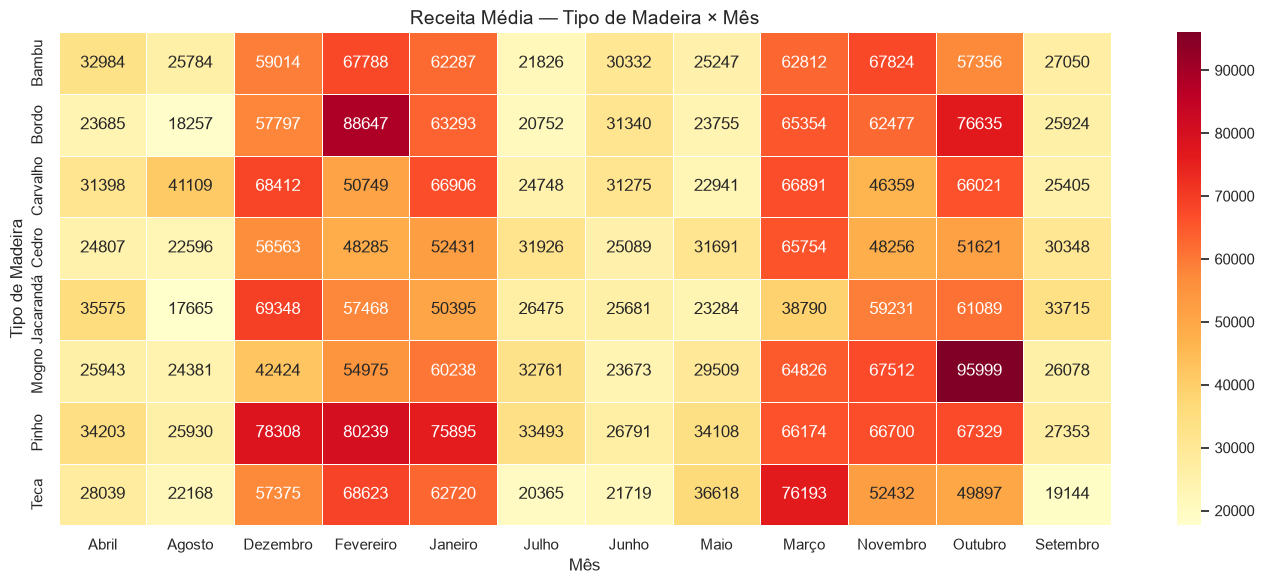

In [40]:
# Bônus B04 — boxplot
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=analisador.df_derivado, x="Tipo de Madeira", y="Receita Total",
            hue="Tipo de Madeira", legend=False, palette=CORES, ax=ax)
ax.set_title("Distribuição da Receita por Tipo de Madeira")
ax.set_xlabel("Tipo de Madeira")
ax.set_ylabel("Receita Total (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/graficos/boxplot_receita.png", dpi=150)
plt.show()
plt.close()

# Bônus B04 — mapa de calor
pivot = analisador.df_derivado.pivot_table(
    values="Receita Total", index="Tipo de Madeira",
    columns="Mês Nome", aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Receita Média — Tipo de Madeira × Mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Tipo de Madeira")
plt.tight_layout()
plt.savefig("outputs/graficos/heatmap_receita.png", dpi=150)
plt.show()
plt.close()

B05 — Percentis

In [41]:
# Bônus B05 — percentis
receitas = analisador.df_derivado["Receita Total"].to_numpy()

p25 = np.percentile(receitas, 25)
p50 = np.percentile(receitas, 50)
p75 = np.percentile(receitas, 75)

print("=" * 45)
print("  BÔNUS B05 — PERCENTIS DA RECEITA TOTAL")
print("=" * 45)
print(f"  P25 (Q1): R$ {p25:>12,.2f}")
print(f"  P50 (Q2): R$ {p50:>12,.2f}")
print(f"  P75 (Q3): R$ {p75:>12,.2f}")
print("=" * 45)

  BÔNUS B05 — PERCENTIS DA RECEITA TOTAL
  P25 (Q1): R$    18,374.79
  P50 (Q2): R$    35,115.59
  P75 (Q3): R$    59,788.04
